# Analysis codebook: JOB meeting minutes

This codebook walks through how we explored the corpus, in the same order the team actually worked: we performed exploratory **LDA** on lemmatized text, primary **BERTopic** modeling on raw text bundled in `raw_documents.pkl`, and **n-gram** frequency trends for interpretable keywords over time.

## Table of Contents

- [Why LDA appears first but is not the final topic model?](#section-why-lda)
- [Sections and contributors](#section-contributors)
- [Section 1 — LDA exploratory modeling](#section-1-lda)
- [LDA process notes](#section-lda-notes)
- [Section 2 — BERTopic](#section-2-bertopic)
- [Section 3 — N-gram frequency analysis](#section-3-ngram)

<a id="section-why-lda"></a>
## Why LDA appears first but is not the final topic model

LDA was used for **iterating on stopwords and cleaning** on `lemmatized_text.xz`; those decisions fed back into preprocessing and into BERTopic's manual stopword list. Even after many runs, LDA topics were hard to tie to substantive jail-oversight themes, and stratifications such as warden tenure often showed **one dominant topic** with little usable structure in the remainder. This was consistent with **topic collapse** under bag-of-words assumptions on long, heterogeneous minutes.

**BERTopic** became the main topic-modeling story because dense embeddings preserve phrasing and context better than LDA for this setting. The notebook keeps one LDA modeling pass, then a concise **process notes** subsection summarizing further iterations; **BERTopic** and **n-grams** follow.

<a id="section-contributors"></a>
## Sections and contributors

| # | Section | Main contributor |
|---|---------|------------------|
| 1 | LDA exploratory modeling | Afifa Iqbal |
| 2 | BERTopic | Samiha Islam |
| 3 | N-gram frequency analysis | Matteo Secomandi |

AI assistance (Claude, Copilot, Gemini) is noted at the start of each section where it applies.


<a id="section-1-lda"></a>

## 1. LDA exploratory modeling

We start from lemmatized documents, build vectorizations, and fit LDA to see which themes and vocabulary dominate. This pass set the agenda for custom stopwords and later preprocessing choices.

- **Main contributor:** Afifa Iqbal.
- AI assistance: **Claude**. Many changes here reflect repeated LDA runs and stopword iteration.

## Topic modeling with LDA

### Import libraries and lemmatized text data:


In [ ]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Set up paths, taken from preprocessing notebooks
from pathlib import Path

BASE = Path("..").resolve()
OUT_DIR = BASE / "Data" / "Text" # where lemmatized text is stored

path = OUT_DIR / 'lemmatized_text.xz'

# Adapted from UDA Clustering on Text.ipynb
import pickle

with open(path, 'rb') as f:
    documents = pickle.load(f)



#print(f'Number of documents: {len(documents)}')
#print(f'Document # 1:{documents[0]}')
#print(f'Document # 1:{len(documents[0])}')
#print('---------------------------------------------------------------------------\n')
#print(f'Document # 77:{documents[76]}')
#print(f'Document # 77:{len(documents[76])}')
#print('---------------------------------------------------------------------------\n')
#print(f'Document # 156{documents[155]}')
#print(f'Document # 156:{len(documents[155])}')

f#or i, doc in enumerate(documents):
  #  print(f'Document {i}: {len(doc)}')

print(len(documents))

156


## Cleaning the Lammatized Text 
**Steps taken:**
- removing the documents which are empty
- removing the digits and numbers (except for years)
- removing custom stop words based on the analysis from LDA so far
- Creating another document list which contains under 10k words, in case that helps with the situation of repeatetive words

In [4]:
print([i for i, doc in enumerate(documents) if len(doc) == 0]) # confirm that there are no more empty docs

[]


In [ ]:
filtered_docs = []
filtered_names = []

for i, doc in enumerate(documents):
    if len(doc) > 0:  # only keep non-empty documents
        filtered_docs.append(doc)
        # filtered_names.append(doc_names[i])
        
print(len(filtered_docs))

156


In [7]:
cleaned_docs = []
for doc in filtered_docs:
    cleaned_tokens = [
        word for word in doc
        if not word.isdigit()  # removing numbers as they were showing up as the frequent words in the vocab list
        or (word.isdigit() and len(word) == 4 and word.startswith(('19', '20')))] # keeping years to help with policy questions related to time
    cleaned_docs.append(cleaned_tokens)

In [8]:
print(len(cleaned_docs))

156


In [9]:
print(type(cleaned_docs))

<class 'list'>


In [10]:
# creating a stop words list by reviewing the most frequent words which are not meaningful 
# these words were observed in the initial LDA model 

from collections import Counter
all_words = [word for doc in cleaned_docs for word in doc]
word_counts = Counter(all_words)
print(word_counts.most_common(300))

[('people', 5709), ('time', 4822), ('deputy', 4445), ('work', 4050), ('individual', 3981), ('question', 3920), ('need', 2941), ('staff', 2781), ('month', 2738), ('provide', 2578), ('health', 2565), ('program', 2480), ('use', 2471), ('day', 2375), ('issue', 2143), ('medical', 2084), ('facility', 2065), ('year', 2014), ('chief', 1967), ('number', 1863), ('good', 1850), ('new', 1805), ('information', 1792), ('receive', 1621), ('state', 1559), ('mental', 1526), ('service', 1518), ('job', 1517), ('incarcerated', 1515), ('process', 1482), ('release', 1469), ('request', 1400), ('pod', 1395), ('community', 1350), ('care', 1308), ('start', 1306), ('continue', 1292), ('week', 1272), ('tablet', 1239), ('book', 1202), ('change', 1201), ('send', 1189), ('answer', 1183), ('population', 1174), ('training', 1167), ('department', 1145), ('policy', 1093), ('hour', 1077), ('include', 1061), ('contract', 1054), ('family', 1043), ('concern', 1040), ('employee', 1037), ('place', 1036), ('unit', 1026), ('res

In [11]:
custom_stop_words = [
    # fillers during conversations - should not be meaningful
    'know', 'think', 'want', 'okay', 'thank',
    'actually', 'thing', 'ask', 'look', 'say', 'yes', 'yeah', 'sure',
    'oh', 'sorry', 'maybe', 'lot', 
    'let', 'bring', 'tell', 'come', 'happen', 'hear',
    'speak', 'try', 'find', 'understand', 'able',
    'way', 'today', 'anybody', 'everybody', 'somebody', 'guy', 'folk',
    'far', 'past', 'long', 'different', 'specific', 'specifically',
    'currently', 'actually', 'forward', 'outside', 'available', 'little',
    'couple', 'ago', 'appreciate', 'mention', 'run', 'add', 'end', 'page'
    
    # some of the single letters are showing up as frequent words
    'e', 't', 's', 'o', 'n', 'r', 'h', 'w', 'c', 'd', 'l', 'g',
    'f', 'p', 'u', 'm', 'y', "'"
    
    # meeting formal words
    'meeting', 'motion', 'second', 'approve', 'adjourn', 'report',
    'member', 'present', 'minute', 'vote', 'board', 'committee',
    'comment', 'public', 'business', 'follow', 'address', 'discussion',
    'record', 'hold', 'begin', 'complete', 'submit', 'review', 'executive', 'president',
    
    # places/locations
    'allegheny', 'county', 'pennsylvania', 'pittsburgh',
    
    # names of specific board numbers maybe?
    'hallam', 'evashavik', 'howsie', 'beasom', 'lazzara', 'brinkman',
    'toma', 'bigley', 'innamorato', 'damick', 'wagner', 'moss',
    'klein', 'perkins', 'williams', 'clark', 'bethany', 'ludwig', 'mcdaniel', 'ron', 'dana', 'chuck', 'doug',
    'larry', 'pofi', 'acchs', 'martoni', 'madarino', 'catanese',
    'phillips', 'donna', 'jo', 'joe', 'orlando', 'harper', 'latoya',
    'mullen', 'fitzgerald', 'asturi', 'carol', 'hertz', 'mike',
    'gilmore', 'marion', 'chelsa', 'william', 'dilucente', 'cashman',
    'walker', 'corizon', 'wingard', 'trevor', 'defazio', 'korinski'
]

In [14]:
print (ENGLISH_STOP_WORDS)

frozenset({'or', 'wherein', 'its', 'an', 'because', 'themselves', 'with', 'your', 'as', 'less', 'about', 'herself', 'amoungst', 'nevertheless', 'now', 'nobody', 'hence', 'by', 'whereafter', 'another', 'may', 'somewhere', 'do', 'becomes', 'alone', 'eleven', 'give', 'a', 'latter', 'ie', 'everywhere', 'moreover', 'nothing', 'several', 'them', 'some', 'itself', 'well', 'put', 'made', 'whether', 'bottom', 'almost', 'whence', 'fill', 'due', 'third', 'this', 'above', 'eg', 're', 'top', 'perhaps', 'they', 'indeed', 'next', 'had', 'mine', 'most', 'before', 'in', 'too', 'than', 'front', 'all', 'otherwise', 'else', 'whereas', 'her', 'if', 'side', 'nor', 'hers', 'these', 'onto', 'without', 'anywhere', 'system', 'besides', 'etc', 'beyond', 'become', 'during', 'here', 'at', 'from', 'against', 'seems', 'often', 'can', 'out', 'whom', 'never', 'formerly', 'also', 'whither', 'un', 'more', 'find', 'me', 'amongst', 'inc', 'rather', 'interest', 'however', 'him', 'first', 'yet', 'where', 'must', 'go', 'eigh

In [15]:
## based on the LDA Analysis that was done before

recurring_commenter_words = [
    'condom', 'stabilization', 'exorbitant', 'clowney', 
    'denial', 'intentionally', 'firsthand', 'unanswered',
    'revisit', 'indication', 'challenging', 'destroy',
    'hell', 'judgment', 'behave', 'comprise', 'desperately',
    'opposition', 'audio', 'owner', 'technological', 'wow',
    'traumatic', 'blame', 'horrible', 'frustration', 'rescind'
]
custom_stop_words.extend(recurring_commenter_words)

In [16]:
# Source - https://stackoverflow.com/a/46328592
# Posted by PyRsquared
# Retrieved 2026-04-22, License - CC BY-SA 3.0

stop_words_removed_doc = [
    [word for word in doc if word not in custom_stop_words]
    for doc in cleaned_docs]

In [18]:
#print(f'Number of documents: {len(stop_words_removed_doc)}')
#print(f'Document # 1:{len(stop_words_removed_doc[0])}')
#print('---------------------------------------------------------------------------\n')
#print(f'Document # 1:{len(stop_words_removed_doc[76])}')
#print('---------------------------------------------------------------------------\n')
#print(f'Document # 1:{len(stop_words_removed_doc[155])}')


# this step is being done to understand how many words are being lost due to the custom stop words
# and to figure out if there are unreasonable long docs 
for i, (doc1, doc2) in enumerate(zip(filtered_docs, stop_words_removed_doc)):
    print(f"Document {i+1}: Original = {len(doc1)} words | Cleaned = {len(doc2)} words")
    if len(doc2) > 10000:
        print(f"--------------------------- Document {i+1}: Cleaned = {len(doc2)} words ------------------------------")

# it was noticed that some of the documents had a large number of words, as compared to the rest
# to ensure that it is not creating the issue in the model, another test lammatized text is being created to check the LDA Model

docs_10k = []
docs_10k_names = []
for i, doc in enumerate(stop_words_removed_doc):
    if len(doc) < 10000:  # only keep less than 10k words documents
        #print(f"--------------------------- Document {i+1}: Cleaned = {len(doc)} words ------------------------------")
        docs_10k.append(doc)
        # docs_10k_names.append(doc_names[i])
        
print (f'\n Number of Documents Containing Less than 10K words:{len(docs_10k)}')

Document 1: Original = 143 words | Cleaned = 143 words
Document 2: Original = 268 words | Cleaned = 268 words
Document 3: Original = 258 words | Cleaned = 258 words
Document 4: Original = 358 words | Cleaned = 358 words
Document 5: Original = 110 words | Cleaned = 110 words
Document 6: Original = 404 words | Cleaned = 404 words
Document 7: Original = 246 words | Cleaned = 246 words
Document 8: Original = 485 words | Cleaned = 485 words
Document 9: Original = 246 words | Cleaned = 246 words
Document 10: Original = 383 words | Cleaned = 383 words
Document 11: Original = 184 words | Cleaned = 184 words
Document 12: Original = 190 words | Cleaned = 190 words
Document 13: Original = 409 words | Cleaned = 409 words
Document 14: Original = 317 words | Cleaned = 317 words
Document 15: Original = 513 words | Cleaned = 513 words
Document 16: Original = 343 words | Cleaned = 343 words
Document 17: Original = 537 words | Cleaned = 537 words
Document 18: Original = 428 words | Cleaned = 428 words
D

In [19]:
print(stop_words_removed_doc[0][:70])

['monthly', 'thursday', 'october', '2012', 'house', '4:00', 'p.m.', 'chief', 'defender', 'rich', 'charles', 'sheriff', 'major', 'interested', 'discuss', 'request', 'discuss', 'role', 'concentrate', 'library', 'learning', 'teaching', 'read', 'provide', 'brochure', 'pa', 'prison', 'society', 'supreme', 'rule', 'state', 'pay', 'september', '2012', 'newspaper', 'confinement', 'confine', 'hour', 'solitary', 'confinement', 'solitary', 'confinement', 'finally', 'acting', 'stickman', 'permit', 'voting', 'absentee', 'ballot', 'misdemeanor', 'september', '2012', 'discuss', 'attend', 're-', 'entry', 'state', 'attend', 'sec', 'john', 'wetzel', 'chief', 'probation', 'potinger', 'david', 'hichton', 'u.s.', 'attorney', 'keynote', 'speaker']


In [20]:
#joining the tokenized text into a string for tf-idf

docs_string = [' '.join(doc) for doc in stop_words_removed_doc]
#print(docs_string[0])

docs_string2 = [' '.join(doc) for doc in docs_10k]

### Creating TF-IDF tables to analyze the most frequently used words

##### The following code is used from UDA Topic Modeling code Demo. 

In [21]:
#vocab_size = 10000
from sklearn.feature_extraction.text import TfidfVectorizer

#upon analyzing further, it was found many of the numbers are getting added to the library which are meaningless for our analysis,
#so toekn_parameter was added for it to be only alphabest and at least length of 3

tfidf_vectorizer1 = TfidfVectorizer(max_df=0.7, min_df=15, token_pattern=r'[a-zA-Z]{3,}', max_features=10000)
tfidf1 = tfidf_vectorizer1.fit_transform(docs_string)

tfidf_vectorizer2 = TfidfVectorizer(max_df=0.9,min_df=10,token_pattern=r'[a-zA-Z]{3,}', max_features=5000)
tfidf2 = tfidf_vectorizer2.fit_transform(docs_string)

tfidf_vectorizer3 = TfidfVectorizer(max_df=0.9, min_df=10, token_pattern=r'[a-zA-Z]{3,}', max_features=10000)
tfidf3 = tfidf_vectorizer3.fit_transform(docs_string)

tfidf_vectorizer4 = TfidfVectorizer(max_df=0.9, min_df=15,token_pattern=r'[a-zA-Z]{3,}', max_features=5000)
tfidf4 = tfidf_vectorizer4.fit_transform(docs_string)

tfidf_vectorizer5 = TfidfVectorizer(max_df=0.8, min_df=10, token_pattern=r'[a-zA-Z]{3,}', max_features=7000)
tfidf5 = tfidf_vectorizer5.fit_transform(docs_string)

#----------------------------- Documents having under 10K words Models ------------------------------

tfidf_vectorizer6 = TfidfVectorizer(max_df=0.9, min_df=10, token_pattern=r'[a-zA-Z]{3,}', max_features=5000)
tfidf6 = tfidf_vectorizer6.fit_transform(docs_string2)

tfidf_vectorizer7 = TfidfVectorizer(max_df=0.8, min_df=15, token_pattern=r'[a-zA-Z]{3,}', max_features=7000)
tfidf7 = tfidf_vectorizer7.fit_transform(docs_string2)

tfidf_vectorizer8 = TfidfVectorizer(max_df=0.7, min_df=15, token_pattern=r'[a-zA-Z]{3,}', max_features=10000)
tfidf8 = tfidf_vectorizer8.fit_transform(docs_string2)

tfidf_vectorizer9 = TfidfVectorizer(max_df=0.8, min_df=10, token_pattern=r'[a-zA-Z]{3,}', max_features=10000)
tfidf9 = tfidf_vectorizer9.fit_transform(docs_string2)

tfidf_vectorizer10 = TfidfVectorizer(max_df=0.9, min_df=10, token_pattern=r'[a-zA-Z]{3,}', max_features=10000)
tfidf10 = tfidf_vectorizer10.fit_transform(docs_string2)

# making a list of all to create the loops later on
tfidf_matrices = [tfidf1, tfidf2, tfidf3, tfidf4, tfidf5, 
                  tfidf6, tfidf7, tfidf8, tfidf9, tfidf10]

vectorizers = [tfidf_vectorizer1, tfidf_vectorizer2, tfidf_vectorizer3, tfidf_vectorizer4, tfidf_vectorizer5,
               tfidf_vectorizer6, tfidf_vectorizer7, tfidf_vectorizer8, tfidf_vectorizer9, tfidf_vectorizer10]


In [22]:

# Extract vocabs and print length + tfidf shape
vocabs = []
for idx, (vectorizer, tfidf_matrix) in enumerate(zip(vectorizers, tfidf_matrices)):
    vocab = vectorizer.get_feature_names_out()
    vocabs.append(vocab)
    print(f"TF-IDF {idx+1}: vocab={len(vocab)}, shape={tfidf_matrix.shape}")

TF-IDF 1: vocab=2280, shape=(156, 2280)
TF-IDF 2: vocab=3041, shape=(156, 3041)
TF-IDF 3: vocab=3041, shape=(156, 3041)
TF-IDF 4: vocab=2354, shape=(156, 2354)
TF-IDF 5: vocab=3004, shape=(156, 3004)
TF-IDF 6: vocab=3008, shape=(155, 3008)
TF-IDF 7: vocab=2296, shape=(155, 2296)
TF-IDF 8: vocab=2255, shape=(155, 2255)
TF-IDF 9: vocab=2974, shape=(155, 2974)
TF-IDF 10: vocab=3008, shape=(155, 3008)


### Fitting LDA Model to the Data

##### The following code is used from UDA Topic Modeling code Demo. 

In [23]:


from sklearn.decomposition import LatentDirichletAllocation

lda_configs = [
    {'n_components': 10, 'max_iter': 30, 'random_state': 0},
    {'n_components': 8,  'max_iter': 50, 'doc_topic_prior': 0.1, 'topic_word_prior': 0.01, 
     'learning_method': 'online', 'learning_offset': 50.0, 'random_state': 0},
    {'n_components': 8,  'max_iter': 50, 'learning_offset': 50.0, 'random_state': 0},
]

lda_models = []
topic_word_dists = []
model_labels = []

for tfidf_idx, tfidf_matrix in enumerate(tfidf_matrices):
    for lda_config in lda_configs:
        lda = LatentDirichletAllocation(**lda_config)
        lda.fit(tfidf_matrix)
        
        dist = np.array([row / row.sum() for row in lda.components_])
        
        lda_models.append(lda)
        topic_word_dists.append(dist)
        label = f"TFIDF-{tfidf_idx+1}_LDA-{lda_config['n_components']}topics_iter{lda_config['max_iter']}"
        model_labels.append(label)
        
        print(f"{label}: components shape={lda.components_.shape}, dist shape={dist.shape}")

TFIDF-1_LDA-10topics_iter30: components shape=(10, 2280), dist shape=(10, 2280)
TFIDF-1_LDA-8topics_iter50: components shape=(8, 2280), dist shape=(8, 2280)
TFIDF-1_LDA-8topics_iter50: components shape=(8, 2280), dist shape=(8, 2280)
TFIDF-2_LDA-10topics_iter30: components shape=(10, 3041), dist shape=(10, 3041)
TFIDF-2_LDA-8topics_iter50: components shape=(8, 3041), dist shape=(8, 3041)
TFIDF-2_LDA-8topics_iter50: components shape=(8, 3041), dist shape=(8, 3041)
TFIDF-3_LDA-10topics_iter30: components shape=(10, 3041), dist shape=(10, 3041)
TFIDF-3_LDA-8topics_iter50: components shape=(8, 3041), dist shape=(8, 3041)
TFIDF-3_LDA-8topics_iter50: components shape=(8, 3041), dist shape=(8, 3041)
TFIDF-4_LDA-10topics_iter30: components shape=(10, 2354), dist shape=(10, 2354)
TFIDF-4_LDA-8topics_iter50: components shape=(8, 2354), dist shape=(8, 2354)
TFIDF-4_LDA-8topics_iter50: components shape=(8, 2354), dist shape=(8, 2354)
TFIDF-5_LDA-10topics_iter30: components shape=(10, 3004), dist s

In [24]:
# Step 4 - Print topics for all 30 models
def print_top_words(tf_1d_table, vocab, num_top_words=15):
    sorted_tuples = sorted(zip(tf_1d_table, vocab), reverse=True)[:num_top_words]
    for _, word in sorted_tuples:
        print(word, end=' ')
    print()

for model_idx, (dist, label) in enumerate(zip(topic_word_dists, model_labels)):
    tfidf_idx = model_idx // 3   # which tfidf this model used
    vocab = vocabs[tfidf_idx]    # get matching vocab
    
    print(f"\n{'='*60}")
    print(f"Model: {label}")
    print(f"{'='*60}")
    
    for topic_idx in range(dist.shape[0]):
        print(f"[Topic {topic_idx}]")
        print_top_words(dist[topic_idx], vocab)


Model: TFIDF-1_LDA-10topics_iter30
[Topic 0]
ring formally shock laugh satisfy plea postpone disrespect secret brand wheel separately disrespectful discontinue foremost 
[Topic 1]
ring formally shock laugh satisfy plea postpone disrespect secret brand wheel separately disrespectful discontinue foremost 
[Topic 2]
ring formally shock laugh satisfy plea postpone disrespect secret brand wheel separately disrespectful discontinue foremost 
[Topic 3]
ring formally shock laugh satisfy plea postpone disrespect secret brand wheel separately disrespectful discontinue foremost 
[Topic 4]
ring formally shock laugh satisfy plea postpone disrespect secret brand wheel separately disrespectful discontinue foremost 
[Topic 5]
ring formally shock laugh satisfy plea postpone disrespect secret brand wheel separately disrespectful discontinue foremost 
[Topic 6]
ring formally shock laugh satisfy plea postpone disrespect secret brand wheel separately disrespectful discontinue foremost 
[Topic 7]
ring form

In [25]:
problem_phrases = ['condom', 'stabilization', 'exorbitant', 'clowney']
for phrase in problem_phrases:
    docs = [(i, filtered_names[i]) for i, doc in enumerate(stop_words_removed_doc) if phrase in doc]
    print(f"'{phrase}': {docs}")

'condom': []
'stabilization': []
'exorbitant': []
'clowney': []


<a id="section-lda-notes"></a>

After the main LDA code above, this subsection records **what was tried across iterations** (including work that originally lived in a second LDA notebook), and why we moved on to BERTopic.

## LDA Topic Modeling — Process Notes & Challenges

### What Was Tried

**Preprocessing iterations:**
- Removed blank documents (3 documents: indices 34, 43, 44)
- Removed numbers and digits, keeping only 4-digit years
- Applied custom stop words list (iteratively expanded over multiple runs) covering:
  - Conversational fillers (okay, yeah, think, know, etc.)
  - Single letters appearing as artifacts
  - Formal meeting procedural words (motion, second, approve, etc.)
  - Geographic boilerplate (allegheny, county, pittsburgh)
  - Board member and staff names (based on the output of different models)
- Tried document truncation to 2000 & 5000 tokens to address document length imbalance

**Vectorization approaches tried:**
- TF-IDF with multiple parameter combinations (max_df: 0.5-0.9, min_df: 5-15, max_features: 500-5000)
- CountVectorizer as an alternative to TF-IDF
- token_pattern restricted to letters only, minimum 3 characters
  
**LDA configurations tried:**
- Number of topics: 3, 5, 8, 10
- max_iter: 30, 50, 100, 500 (some might not be there now, since they have been tested and weren't find to be helpful)
- Varying doc_topic_prior (0.01, 0.1) and topic_word_prior (0.001, 0.01)
- learning_offset: 50.0
- 30 total model combinations across 10 TF-IDF configurations in the older code notebook
- 5 being tested in this notebook

---

### Persistent Issue: Topic Collapse

Throughout all iterations, LDA consistently produced **topic collapse** — where one topic dominates the probability distribution while all others are near-zero. For example:

- LDA with Less Token Documents topic sums:28.675584, 28.66462407, 28.64178601, 28.6902225, 2541.25328196,28.61286945, 28.62453954, 28.63004241

So, LDA is assigning nearly all words (probability) to a single topic (such as 2541 for one topics as compared to 28 for rest) instead of trying to find distinct theme.

### Most Reasonable (sane T_T) Output
After trying different models, most reasonable output is observed when the documents were truncated to 2000/5000 (both were tested) tokens.


<a id="section-2-bertopic"></a>

## 2. BERTopic

We switch to transformer embeddings and BERTopic, using raw meeting text from `Data/Combined/raw_documents.pkl` (with year and month from the same bundle) so document order and metadata stay aligned.

- **Main contributor:** Samiha Islam
- AI assistance: **GitHub Copilot**

## Topic modeling with BERTopic

### Import libraries and data

If transformers and BERTopic are not already installed, use `!pip install transformers` and `!pip install bertopic`.


In [40]:
from transformers import AutoTokenizer, AutoModel
import torch
from pathlib import Path
import pickle
import numpy as np
from bertopic import BERTopic

# Load BERT Tokenizer and Model

In [41]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
embedding_model = AutoModel.from_pretrained('bert-base-uncased')

### Load documents

Raw meeting text, **year**, and **month** are loaded from `Data/Combined/raw_documents.pkl` (built in preprocessing: text from extracted `.txt` files; year and month parsed from filenames `YYYY_M_...`).

BERT works better on raw text than on the lemmatized version used for LDA. The warden tenure analysis under the older bag-of-words setup was basically only showing one dominant topic for all three periods, and the remaining topics were not insightful, even after continuing to remove stopwords.


In [42]:
BASE = Path("..").resolve()
path = BASE / "Data" / "Combined" / "raw_no_junk.pkl"

with open(path, "rb") as f:
    data = pickle.load(f)

raw_docs = data["documents"]
years = data["years"]
months = data["months"]
# Alias used later when building the topic dataframe
documents = raw_docs


# Filter stopwords
First, manually define words that are meaningless and came up frequently from the preprocessing for the LDA and n-gram analysis. 

In [43]:
manual_stop_words = [
    # names as found during the n-gram analysis
    'judge court', 'judge joseph', 'judge judge', 'mr .', 'sheriff department',
    'sheriff kevin', 'sheriff office', 'sheriff william', 'warden address',
    'warden administrative', 'warden answer', 'warden chief', 'warden deputy',
    'warden good', 'warden jail', 'warden jason', 'warden judge', 'warden know',
    'warden like', 'warden long', 'warden respond', 'warden staff', 'warden state',
    'warden talk', 'warden think', 'warden update', 'warden want', 'warden warden',
    'warden work', 'warden ms.', 'warden provide', 'warden response', 'warden search',

    # fillers during conversations - should not be meaningful
    'know', 'think', 'want', 'okay', 'thank', 'like',
    'actually', 'thing', 'ask', 'look', 'say', 'yes', 'yeah', 'sure',
    'oh', 'sorry', 'maybe', 'lot', 
    'let', 'bring', 'tell', 'come', 'happen', 'hear',
    'speak', 'try', 'find', 'understand', 'able',
    'way', 'today', 'anybody', 'everybody', 'somebody', 'guy', 'folk',
    'far', 'past', 'long', 'different', 'specific', 'specifically',
    'currently', 'actually', 'forward', 'outside', 'available', 'little',
    'couple', 'ago', 'appreciate', 'mention', 'run', 'add', 'end', 'page',
    
    # some of the single letters are showing up as frequent words
    'e', 't', 's', 'o', 'n', 'r', 'h', 'w', 'c', 'd', 'l', 'g',
    'f', 'p', 'u', 'm', 'y', "'",
    
    # meeting formal words
    'meeting', 'motion', 'second', 'approve', 'adjourn', 'report',
    'member', 'present', 'minute', 'vote', 'board', 'committee',
    'comment', 'public', 'business', 'follow', 'address', 'discussion',
    'record', 'hold', 'begin', 'complete', 'submit', 'review', 'executive', 'president',
    
    # places/locations
    'allegheny', 'county', 'pennsylvania', 'pittsburgh',
    
    # names of specific board members
    'hallam', 'evashavik', 'howsie', 'beasom', 'lazzara', 'brinkman',
    'toma', 'bigley', 'innamorato', 'damick', 'wagner', 'moss',
    'klein', 'perkins', 'williams', 'clark', 'bethany', 'ludwig', 'mcdaniel', 'ron', 'dana', 'chuck', 'doug',
    'larry', 'pofi', 'acchs', 'martoni', 'madarino', 'catanese',
    'phillips', 'donna', 'jo', 'joe', 'orlando', 'harper', 'latoya',
    'mullen', 'fitzgerald', 'asturi', 'carol', 'hertz', 'mike',
    'gilmore', 'marion', 'chelsa', 'william', 'dilucente', '-dilucente', 'cashman',
    'walker', 'corizon', 'wingard', 'trevor', 'defazio', 'korinski',
    'dilucente', 'right', 'talk', 'man', 'hood', 'price', 'griffin', 'officer', 'connor', 'acj', 'mean', 'zak', 'person',
    'visit', 'beth', 'ali', 'kroll', 'davis', 'martin', 'judgeclark', "o'connor", 'kimberly', 'm.', 'gayle', 'elliott',

    # titles, prefixes, and other noticed words/characters with little or no meaning
    '.', '-', 'mr', 'ms', 'mr.', 'ms.', 'dr.', 'dr', 'inmate', 'jail', 'judge', 'warden', 'report', 'oversight', 'board',
    'conference', 'room', 'court', 'honorable', '00', '000', '000incarceratedindividual', '00am', '00o', '00p', '00pm',
    '01', '015', '02', '023', '03', '038', '04', '040', '048', '05', '050', '06', '069',
    'actions', 'mrs', 'following', 'duly', 'unanimously', 'approval', 'agreement', 'share', 'austin', 'party', 'respectfully', 
    'adjournment', 'secretary', 'parole', 'distribute', 'inform', 'mrs.', 'represent',

    # other words that are showing up as frequent but are not meaningful
    'people', 'time', 'work', 'individual', 'question', 'staff', 'month', 'state', 'pm', 'am', 'staff', 'deputy', 'sheriff',
    'new', 'day', 'time', 'program', 'use', 'regard', 'year', 'number', 'p.m.'
]

Add extra stopwords that came up during earlier runs of BERTopic and standardize the formatting so we have a list of clean stop words

In [90]:

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
clean_stopwords = set()
for w in manual_stop_words:
    w = w.lower().strip()
    if w.isalpha():
        clean_stopwords.add(w)

clean_stopwords = clean_stopwords.union(ENGLISH_STOP_WORDS)

extra_stopwords = {
    "jail", "inmate", "inmates", "warden", "judge", "board", "county",
    "ms", "mr", "mrs", "dr", "hallam", "clark", "evashavik", "howsie",
    "motion", "approve", "meeting", "committee", "public", "comment",
    "report", "services", "oversight", "galvin", "fax", "reporting", "services",
    "stated", "individuals", "representing", "going", "just", "im", "dont", "thats", "youre", 
    "theyre", "did", "make", "just", "ok", "okay", "yeah", "um", "uh", "right", "like", "got", "get",
    "chief", "approved", "seconded", "minutes", "reported",
    "asked", "said", "really", "things", "need", "does", "did", "make",
    "comments", "questions", "job", "facility", "center", "members",
    "population", "community", "going", "just", "hon", "don", "mane", "oconnor",
    "kim", "berkeley", "catena"
}

clean_stopwords = clean_stopwords.union(extra_stopwords)



Convert stopwords to list for CountVectorizer

In [91]:
clean_stopwords = list(clean_stopwords)

Remove additional terms that come up in runs of BERTopic

In [92]:

import re

def clean_minutes(text):
    text = text.lower()
    text = re.sub(r"page \d+ of \d+", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"\b\d{1,2}:\d{2}\b", " ", text)
    text = re.sub(r"\b(mr|ms|mrs|dr)\s+[a-z]+\b", " ", text)
    text = re.sub(r"allegheny county jail oversight board", " ", text)
    text = re.sub(r"monthly meeting", " ", text)
    text = re.sub(r"motion to approve", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_docs = [clean_minutes(doc) for doc in raw_docs]


In [93]:
from bertopic import BERTopic
from hdbscan import HDBSCAN
import umap
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words=clean_stopwords,
    max_features=7000,
    ngram_range=(1,2),
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b",
  )

Set UMAP paramaters

In [84]:
umap_model = umap.UMAP(
    n_neighbors=25,       # more local structure
    n_components=10,      # higher-dimensional space
    min_dist=0.0,         # tightens clusters
    metric='cosine',
    random_state=42
)


Set HDBSCAN parameters

In [85]:
hdbscan_model = HDBSCAN(
    min_cluster_size=5,          # smaller clusters 
    min_samples=1,               # less conservative
    cluster_selection_epsilon=0.1,  # encourages splitting
    metric='euclidean',
    cluster_selection_method='eom'
)


Run BERTopic

In [94]:
topic_model = BERTopic(
    vectorizer_model=vectorizer,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics=None

)

topics, probs = topic_model.fit_transform(clean_docs)
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_custody_dady_dhsa shaw_administrative custody,"[custody, dady, dhsa shaw, administrative cust...","[the of the was held on thursday, march , , in..."
1,0,74,0_health_controller_mental_women,"[health, controller, mental, women, inquired, ...","[the of the was held on thursday december , in..."
2,1,22,1_incarcerated_health_training_covid,"[incarcerated, health, training, covid, provid...","[the of the was held on thursday, april , held..."
3,2,18,2_medical_officers_incarcerated_good,"[medical, officers, incarcerated, good, inform...","[meeting thursday september , gold room 4th fl..."
4,3,12,3_saying_working_officers_good,"[saying, working, officers, good, issues, info...","[meeting thursday december , gold room 4th flo..."
5,4,10,4_hsa_books_medical_health,"[hsa, books, medical, health, incarcerated, in...","[meeting thursday april , gold room 4th floor ..."
6,5,8,5_health_books_covid_ve,"[health, books, covid, ve, department, employe...","[the of the was held thursday, august , held a..."
7,6,5,6_fund_ve_welfare_suicide,"[fund, ve, welfare, suicide, family, provide, ...",[| p a g e the of the was held on thursday oct...
8,7,5,7_percent_hsa_council_healthcare,"[percent, hsa, council, healthcare, incarcerat...","[meeting thursday october , gold room 4th floo..."


Check top words and probabilities by topic

In [95]:
for topic_id in topic_info.Topic:
    print(f"\nTopic {topic_id}")
    print(topic_model.get_topic(topic_id))


Topic -1
[('custody', 0.027229559335615817), ('dady', 0.02537346089904328), ('dhsa shaw', 0.019972907706464323), ('administrative custody', 0.01846265224964186), ('days', 0.018410122646148188), ('medical', 0.017640192499707736), ('folks', 0.017453868273059163), ('shaw', 0.017223184639524342), ('disciplinary custody', 0.016682413579685976), ('working', 0.01633458532157313)]

Topic 0
[('health', 0.027127250588815006), ('controller', 0.01711447896352571), ('mental', 0.01550890002480289), ('women', 0.015344052292951866), ('inquired', 0.014974689321260818), ('goodwill', 0.014971582213585534), ('offenders', 0.014236378521650087), ('pregnant', 0.014105845101365177), ('drug', 0.01403606958307241), ('electronic', 0.01402024835728358)]

Topic 1
[('incarcerated', 0.025938524818848313), ('health', 0.020392449894561775), ('training', 0.016453639231960165), ('covid', 0.015077071001160606), ('provide', 0.014415362571571843), ('information', 0.014106720250860365), ('mental', 0.013381037528746136), ('

Visualize top words by topic

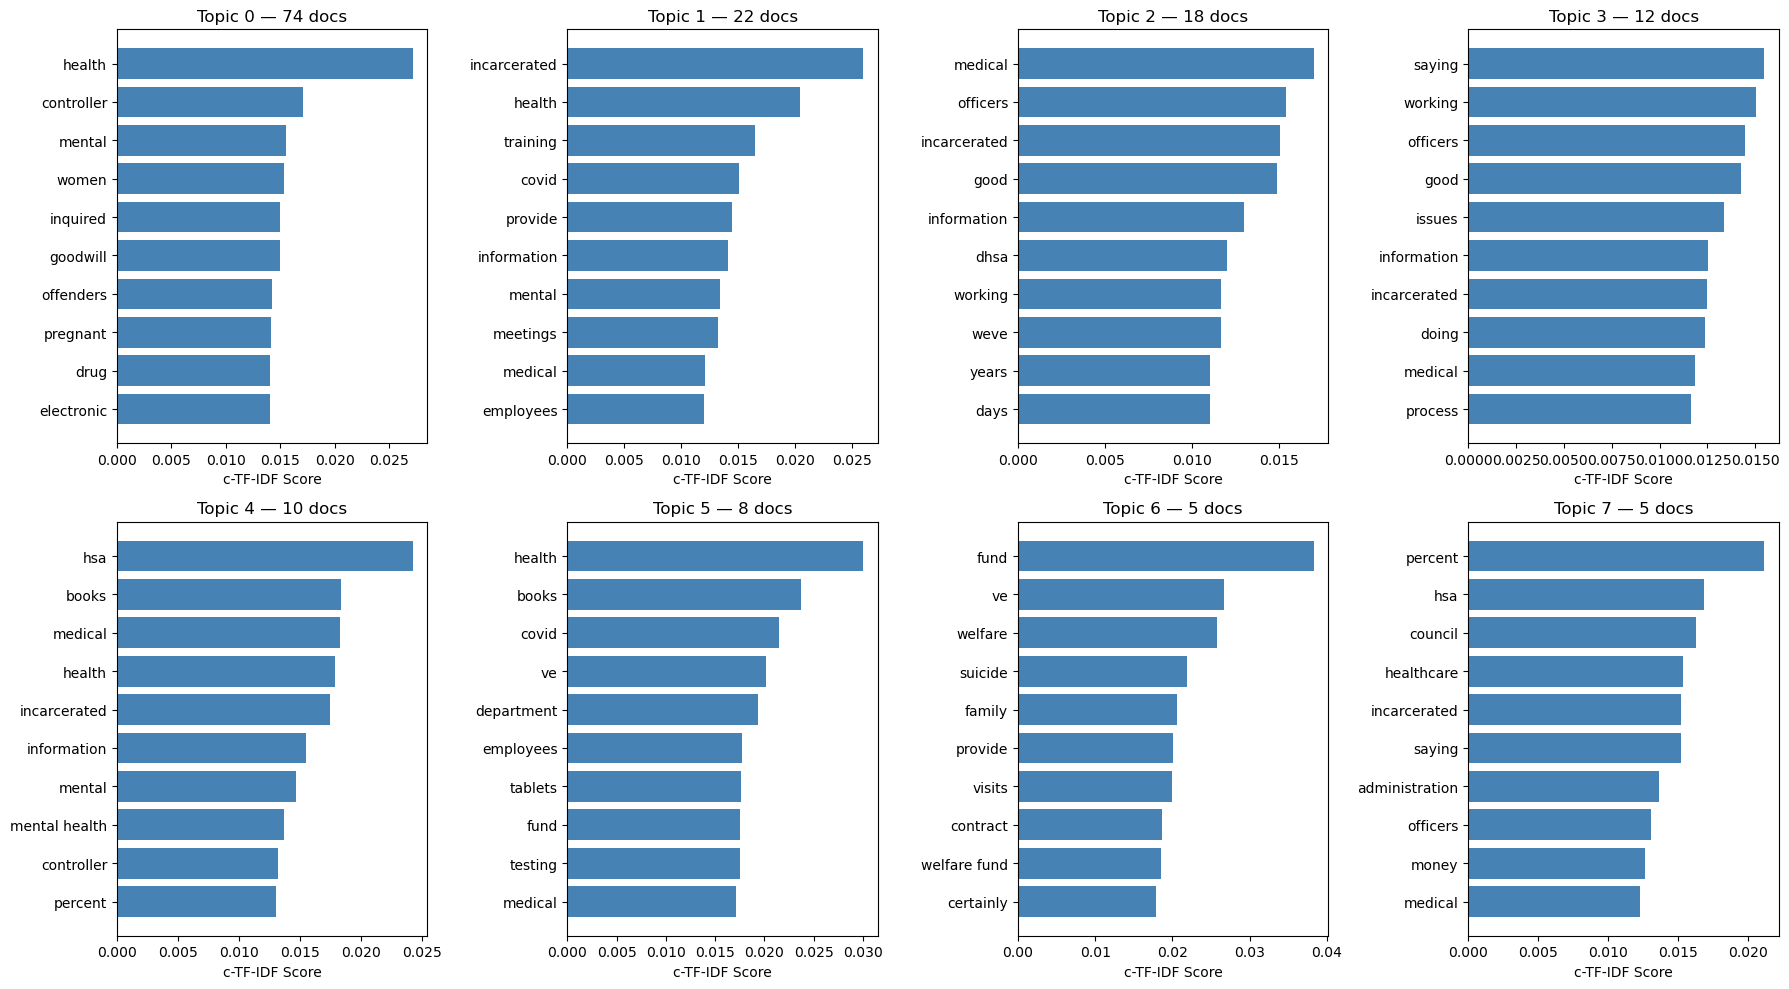

In [96]:
import matplotlib.pyplot as plt

def plot_topic_panels(topic_model, top_n=10):
    topic_info = topic_model.get_topic_info()
    real_topics = [t for t in topic_info.Topic if t != -1]
    n_topics = len(real_topics)

    # Create panel: 2 rows × 4 columns 
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    for ax, topic_id in zip(axes, real_topics):
        # Get count
        count = topic_info.loc[topic_info['Topic'] == topic_id, 'Count'].values[0]

        # Get words
        words = topic_model.get_topic(topic_id)
        words = words[:top_n]
        labels = [w[0] for w in words]
        scores = [w[1] for w in words]

        # Plot
        ax.barh(labels, scores, color='steelblue')
        ax.invert_yaxis()
        ax.set_title(f"Topic {topic_id} — {count} docs")
        ax.set_xlabel("c-TF-IDF Score")

    for j in range(len(real_topics), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Run it
plot_topic_panels(topic_model, top_n=10)


#### Plotting topics as WordClouds (heavily adapted from HW2 solutions)

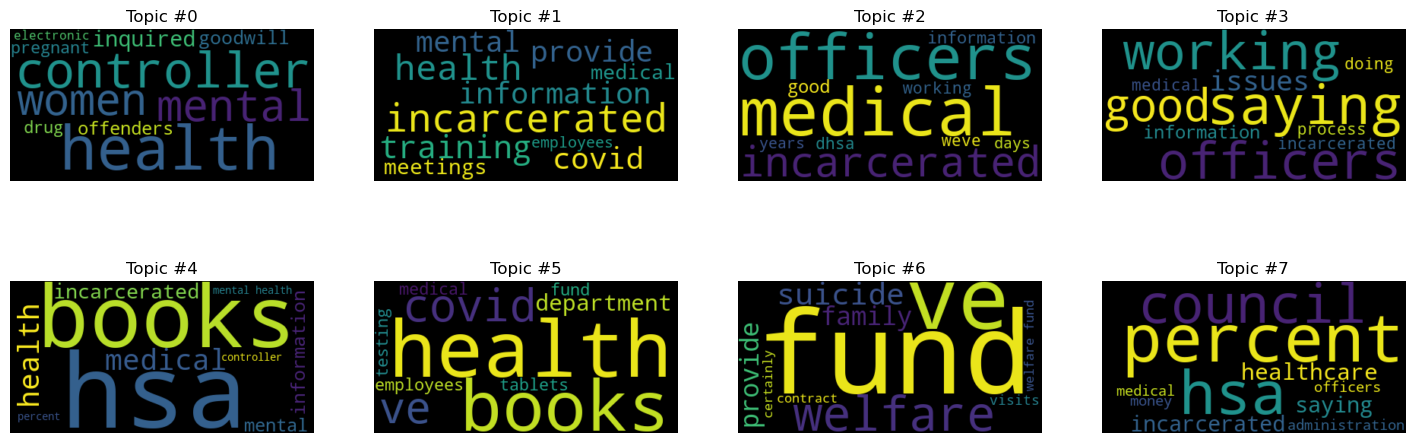

In [97]:
from wordcloud import WordCloud

def plot_word_cloud(ax, tf_1d_table, vocab, num_top_words=20):
    wc = WordCloud(max_words=num_top_words, random_state=0)
    wc.generate_from_frequencies(dict(zip(vocab, tf_1d_table)))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_axis_off()

topic_info = topic_model.get_topic_info()
real_topics = [t for t in topic_info.Topic if t != -1]
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
axes = axes.flatten()

for ax, topic_id in zip(axes, real_topics):
    words = topic_model.get_topic(topic_id)
    words = words[:10]
    labels = [w[0] for w in words]
    scores = [w[1] for w in words]
    
    plot_word_cloud(ax, scores, labels)
    ax.set_title(f'Topic #{topic_id}')

# View Main Topics Across Years
We want to see what the main topics of discussion are under each warden's tenure 
* Tenure 1: Orlando Harper, September 2012 through September 2023
* Tenure 2: Shane Dady, October 2023 through December 2024
* Tenure 3: Trevor Wingard, January 2025 to present


Build the topic dataframe. **Year** and **month** come from `raw_documents.pkl` (same index order as `raw_docs` / `clean_docs`), not from regex on the transcript body.


In [98]:
# years and months were assigned when loading raw_documents.pkl (filename-based metadata)
assert len(years) == len(months) == len(raw_docs), (len(years), len(months), len(raw_docs))
assert len(topics) == len(raw_docs), (len(topics), len(raw_docs))


In [99]:
import pandas as pd
df = pd.DataFrame({
    "document": documents,
    "topic": topics,
    "year": years,
    "month": months,
})


In [100]:
df["year"].max()


2026

Define dates for each warden's tenure

In [101]:
tenure_1 = (
    (df["year"] > 2012) & (df["year"] < 2023)
) | (
    (df["year"] == 2012) & (df["month"] >= 9)
) | (
    (df["year"] == 2023) & (df["month"] <= 9)
)

tenure_2 = (
    (df["year"] == 2023) & (df["month"] >= 10)
) | (
    (df["year"] == 2024)
)

tenure_3 = (
    (df["year"] > 2024) 
) 



Assign each document to a tenure

In [102]:
df["period"] = None
df.loc[tenure_1, "period"] = "Harper"
df.loc[tenure_2, "period"] = "Dady"
df.loc[tenure_3, "period"] = "Wingard"

In [103]:
df["period"].value_counts()

period
Harper     121
Dady        17
Wingard     15
Name: count, dtype: int64

Remove topic=-1, as that represents noise

In [104]:
df_clean = df[df["topic"] != -1]


Show topic distributions by warden tenure period

In [105]:
topic_by_period = (
    df_clean
    .groupby(["period", "topic"])
    .size()
    .unstack(fill_value=0)
)

topic_by_period

topic,0,1,2,3,4,5,6,7
period,,,,,,,,
Dady,0,0,9,5,0,0,0,2
Harper,71,22,0,1,10,8,5,3
Wingard,0,0,9,6,0,0,0,0


The majority of documents are in Harper's tenure, as he was in office for over 10 years and the others were in office for less than 2 years. To give a better sense of the distribution, we calculate the percentage of documents in each topic by tenure

In [106]:
topic_by_period_percent = topic_by_period.div(topic_by_period.sum(axis=1), axis=0) * 100

Display topics for the meeting documents in each warden's tenure


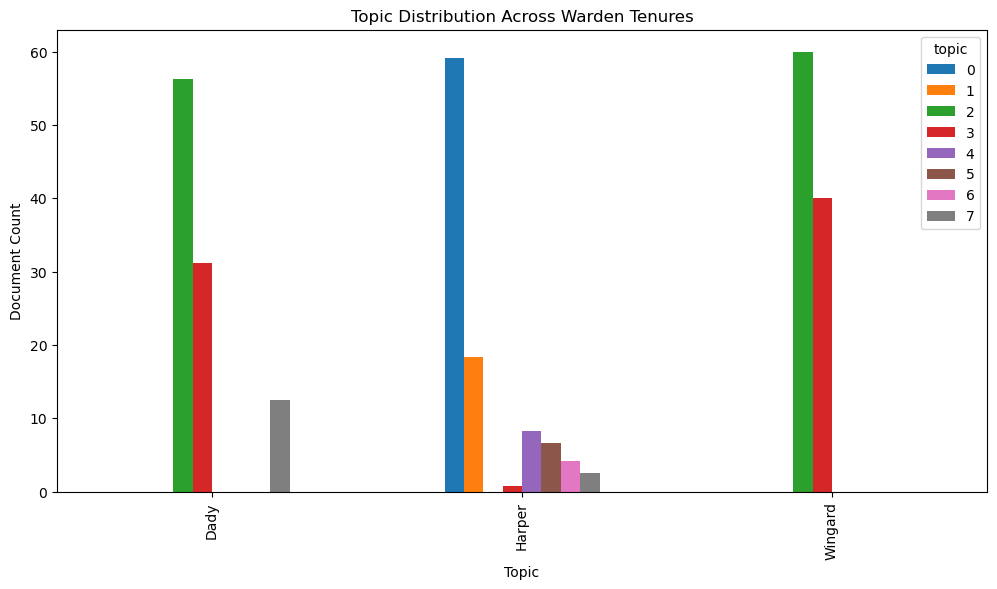

In [107]:
topic_by_period_percent.plot(kind="bar", figsize=(12,6))
plt.title("Topic Distribution Across Warden Tenures")
plt.xlabel("Topic")
plt.ylabel("Document Count")
plt.show()

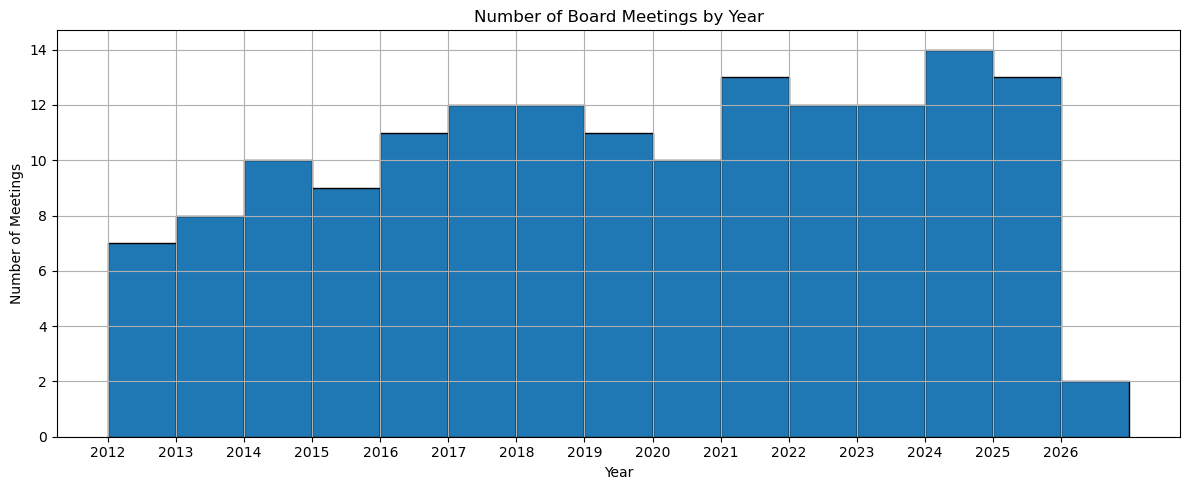

In [109]:
# Check number of meetings per month/year
import matplotlib.pyplot as plt

# Create a year-month combination for plotting
df['year_month'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)

# Plot histogram of meetings by year
fig, ax = plt.subplots(figsize=(12, 5))
df['year'].hist(bins=range(df['year'].min(), df['year'].max() + 2), ax=ax, edgecolor='black')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Meetings')
ax.set_title('Number of Board Meetings by Year')
plt.xticks(sorted(df['year'].unique()))
plt.tight_layout()
plt.show()

# # Show breakdown by year and month
# print("\nMeetings by Year and Month:")
# print(df.groupby(['year', 'month']).size().to_string())

<a id="section-3-ngram"></a>

## 3. N-gram frequency analysis

We summarize recurring phrases and terms on the lemmatized corpus—useful for policy-relevant keywords and for cross-checking topic-model outputs.

- **Main contributor:** Matteo Secomandi
- AI assistance: **Gemini** (debugging)


## N-gram analysis

### Import libraries and lemmatized text data:


In [110]:
import numpy as np
import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt

# Set up paths, taken from preprocessing notebooks
from pathlib import Path

BASE = Path("..").resolve()
OUT_DIR = BASE / "Data" / "Text" # where lemmatized text is stored

path = OUT_DIR / 'lemmatized_text.xz'

# Adapted from UDA Clustering on Text.ipynb
import pickle

with open(path, 'rb') as f:
    documents = pickle.load(f)

print(f'Number of documents: {len(documents)}')
print(documents[0])

Number of documents: 156
['monthly', 'thursday', 'october', '2012', 'house', '4:00', 'p.m.', 'chief', 'defender', 'rich', 'charles', 'sheriff', 'major', 'interested', 'discuss', 'request', 'discuss', 'role', 'concentrate', 'library', 'learning', 'teaching', 'read', 'provide', 'brochure', 'pa', 'prison', 'society', 'supreme', 'rule', 'state', 'pay', 'september', '2012', 'newspaper', 'confinement', 'confine', 'hour', 'solitary', 'confinement', 'solitary', 'confinement', 'finally', 'acting', 'stickman', 'permit', 'voting', 'absentee', 'ballot', 'misdemeanor', 'september', '2012', 'discuss', 'attend', 're-', 'entry', 'state', 'attend', 'sec', 'john', 'wetzel', 'chief', 'probation', 'potinger', 'david', 'hichton', 'u.s.', 'attorney', 'keynote', 'speaker', 'welcome', 'new', 'state', 'promotion', 'warren', 'deputy', 'services', 'program', 'services', 'old', 'naacp', 'floor', 'collect', 'absentee', 'ballot', 'inmates', 'yesterday', 'new', 'correctional', 'health', 'services', 'month', 'collabo

### Data has been loaded in successfully. By looking at the first document, we can see that some date information is included at the start. We begin by testing to see if we can easily extract this information from documents by looking at first couple words. We also address the blank documents issue that was identified by this process.

In [111]:
empty_docs = []

i = 0 # Tracking document indicies in order to manually inspect outliers and track empty docs

for document in documents:
    # Added indicies until almost all had date information
    print(i, document[0:15])
    # Filter for empty_docs
    if len(document) == 0:
        empty_docs.append(i)
    i += 1

empty_docs # We probably want to remove these from analysis

0 ['monthly', 'thursday', 'october', '2012', 'house', '4:00', 'p.m.', 'chief', 'defender', 'rich', 'charles', 'sheriff', 'major', 'interested', 'discuss']
1 ['monthly', 'thursday', 'november', '2012', 'house', '4:00', 'p.m.', 'rich', 'charles', 'sheriff', 'deputy', 'warren', 'major', 'interested', 'discuss']
2 ['monthly', 'thursday', 'december', '2012', 'house', '4:00', 'p.m.', 'sheriff', 'rich', 'charles', 'chief', 'defender', 'deputy', 'warren', 'major']
3 ['monthly', 'thursday', 'march', '2013', 'house', '4:00', 'p.m.', 'sheriff', 'p.', 'rich', 'genie', 'beckom', 'charles', 'deputy', 'monica']
4 ['monthly', 'thursday', '2012', 'house', '4:00', 'p.m.', 'kim', 'charles', 'chief', 'rizzo', 'sheriff', 'acting', 'stickman', 'iii', 'major']
5 ['monthly', 'thursday', 'june', '2012', 'house', '4:00', 'p.m.', 'chief', 'defender', 'rich', 'walt', 'szymanski', 'charles', 'chief', 'rizzo']
6 ['monthly', 'thursday', 'september', '2012', 'house', '4:00', 'p.m.', 'chief', 'defender', 'rich', 'char

[]

### Looking at the distribution of document lengths, it looks like it is heavily left-skewed. It might be interesting to see which of the documents are the super long ones.

There are 156 non-empty documents


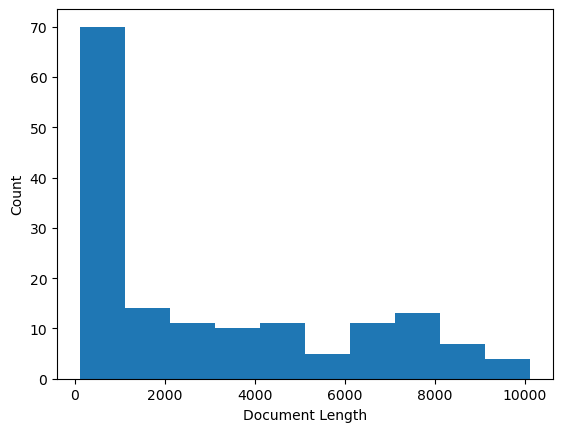

The median document length is 1743.5


In [112]:
# Creating new list of non-empty documents
docs_clean = [documents[i] for i in range(len(documents)) if i not in empty_docs]
print(f'There are {len(docs_clean)} non-empty documents')

# We are also interested in seeing the length of the non-empty docs to see if they are dramatically different
doc_lengths = [len(doc) for doc in docs_clean]
plt.hist(doc_lengths)
plt.xlabel("Document Length")
plt.ylabel("Count")
plt.show()

print(f'The median document length is {pd.Series(doc_lengths).median()}')

In [113]:
# We want to extract the date information from the documents
years = [str(y) for y in range(2012, 2027)]

doc_years = []
no_dates = []
i = 0 

for doc in docs_clean:
    date_string = ''.join(doc[0:15])
    found_year = None
    for year in years:
        if year in date_string:
            found_year = year
            break

    if found_year is None:
        no_dates.append(i)
        doc_years.append(np.nan)
    else:
        doc_years.append(int(found_year))
    i += 1

for i in no_dates:
    print(i, len(docs_clean[i]), docs_clean[i]) # We probably want to find some manual way to add dates or remove

47 513 ['monthly', 'thursday', 'december', '7th', '4:00', 'pm', 'courthouse', 'david', 'controller', 'sheriff', 'ken', 'varhola', 'council', 'john', 'abass', 'kamara', 'attend', 'deputy', 'monica', 'prison', 'society', 'interested', 'newspaper', 'ad', 'time', 'correctional', 'position', 'pg', 'article', 'discuss', 'lawsuit', 'correctional', 'topic', 'mandatory', 'overtime', 'topic', 'pregnant', 'woman', 'segregation', 'solitary', 'note', 'express', 'concern', 'matter', 'recent', 'lawsuit', 'subject', 'regard', 'lawsuit', 'note', 'settlement', 'pay', 'taxpayer', 'money', 'newspaper', 'article', 'importance', 'job', 'training', 'service', 'provide', 'important', 'role', 'play', 'help', 'employment', 'release', 'reduce', 'likelihood', 'enter', 'eighteen', 'juvenile', 'list', 'recent', 'census', 'female', 'good', 'alternative', 'housing', 'unit', 'enable', 'resident', '6,750', 'hour', 'community', 'service', 'commend', 'express', 'confusion', 'regard', 'medical', 'list', 'total', 'pregnant

In [114]:
# Looking at how many documents belong to each year
pd.Series(doc_years).value_counts(dropna=False)

2024.0    14
2025.0    13
2018.0    12
2021.0    12
2022.0    12
2023.0    12
2016.0    11
2017.0    11
2019.0    11
2013.0    10
2014.0    10
2020.0    10
2015.0     8
2012.0     6
NaN        2
2026.0     2
Name: count, dtype: int64

### Next, we create TF and TF-IDF tables to analyze the most frequently used words. The following code is heavily adopted from the HW2 solutions.

In [115]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

vocab_size = 10000

tf_vectorizer = CountVectorizer(
    analyzer='word',
    tokenizer=lambda x: x, 
    preprocessor=lambda x: x,
    token_pattern=None,
    # Arguments above this line necessary to account for the fact that our data has already been lemmatized
    max_df=0.7,
    min_df=2,
    ngram_range=(1, 3), # Looking at n-grams of size 1 to 3
    max_features=vocab_size
)

tf = tf_vectorizer.fit_transform(docs_clean)

idf_transformer = TfidfTransformer()
tfidf = idf_transformer.fit_transform(tf)

In [116]:
vocab = tf_vectorizer.get_feature_names_out()
vocab # Might be good to change pre-processing to remove %, &, •, ’ symbols 

array(['%', '% %', '% employee', ..., 'zoom', 'zuhlke', '|'], dtype=object)

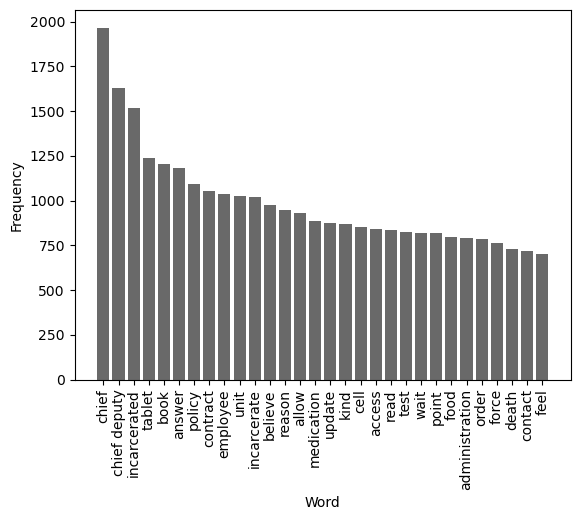

In [117]:
def get_top_words(tf_1d_table, vocab, num_top_words=20):
    return sorted(zip(tf_1d_table, vocab), reverse=True)[:num_top_words]

def print_top_words(tf_1d_table, vocab, num_top_words=20):
    sorted_tuples = get_top_words(tf_1d_table, vocab, num_top_words)

    for _, word in sorted_tuples:
        print(word, end=' ')
    print()

def plot_top_words(tf_1d_table, vocab, num_top_words=20, divide_by_sum=False):
    if divide_by_sum:
        tf_1d_table = tf_1d_table / tf_1d_table.sum()
    sorted_tuples = get_top_words(tf_1d_table, vocab, num_top_words)
    top_counts, top_words = zip(*sorted_tuples)

    plt.bar(range(num_top_words), top_counts, color='dimgray')
    plt.xticks(range(num_top_words), top_words, rotation=90)
    plt.xlabel('Word')
    plt.ylabel('Frequency')

plot_top_words(np.array(tf.sum(axis=0)).flatten(), vocab, num_top_words=30)

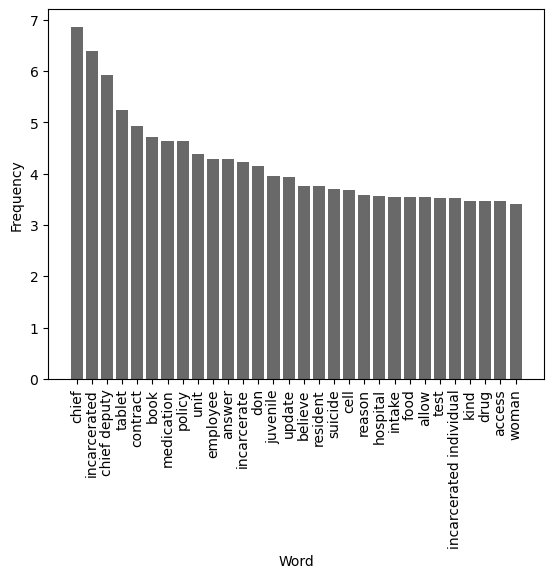

In [9]:
plot_top_words(np.array(tfidf.sum(axis=0)).flatten(), vocab, num_top_words=30)

### No immediate observations from text. We will now try to view n-gram frequency based on year and warden tenure.

In [118]:
# Adding code for identfying dates

import re

def extract_year_month(text):
    # month names
    months = {
        "january": 1, "february": 2, "march": 3, "april": 4,
        "may": 5, "june": 6, "july": 7, "august": 8,
        "september": 9, "october": 10, "november": 11, "december": 12
    }
    
    # find year
    year_match = re.search(r"\b(20\d{2})\b", text)
    year = int(year_match.group(1)) if year_match else None
    
    # find month name
    month_match = re.search(r"(january|february|march|april|may|june|july|august|september|october|november|december)", text.lower())
    month = months[month_match.group(1)] if month_match else None
    
    return year, month

year_month = [extract_year_month(' '.join(doc)) for doc in documents]
years = [ym[0] for ym in year_month]
months = [ym[1] for ym in year_month]

import pandas as pd
df = pd.DataFrame({
    "document": documents,
    "year": years,
    "month": months
})

tenure_1 = (
    (df["year"] > 2012) & (df["year"] < 2023)
) | (
    (df["year"] == 2012) & (df["month"] >= 9)
) | (
    (df["year"] == 2023) & (df["month"] <= 9)
)

tenure_2 = (
    (df["year"] == 2023) & (df["month"] >= 10)
) | (
    (df["year"] == 2024)
)

tenure_3 = df["year"] >= 2025

df["period"] = None
df.loc[tenure_1, "period"] = "Harper"
df.loc[tenure_2, "period"] = "Dady"
df.loc[tenure_3, "period"] = "Wingard"

df.year.value_counts()

year
2024    14
2025    13
2017    12
2018    12
2021    12
2022    12
2023    12
2016    11
2019    11
2013    10
2014    10
2020    10
2015     8
2012     6
2026     2
2004     1
Name: count, dtype: int64

In [119]:
# One year has been classified as 2004 we can replace this with none since it is incorrect

df.year = df.year.replace({2004:None})

df.year.value_counts(dropna=False)

year
2024    14
2025    13
2017    12
2018    12
2021    12
2022    12
2023    12
2016    11
2019    11
2013    10
2014    10
2020    10
2015     8
2012     6
2026     2
None     1
Name: count, dtype: int64

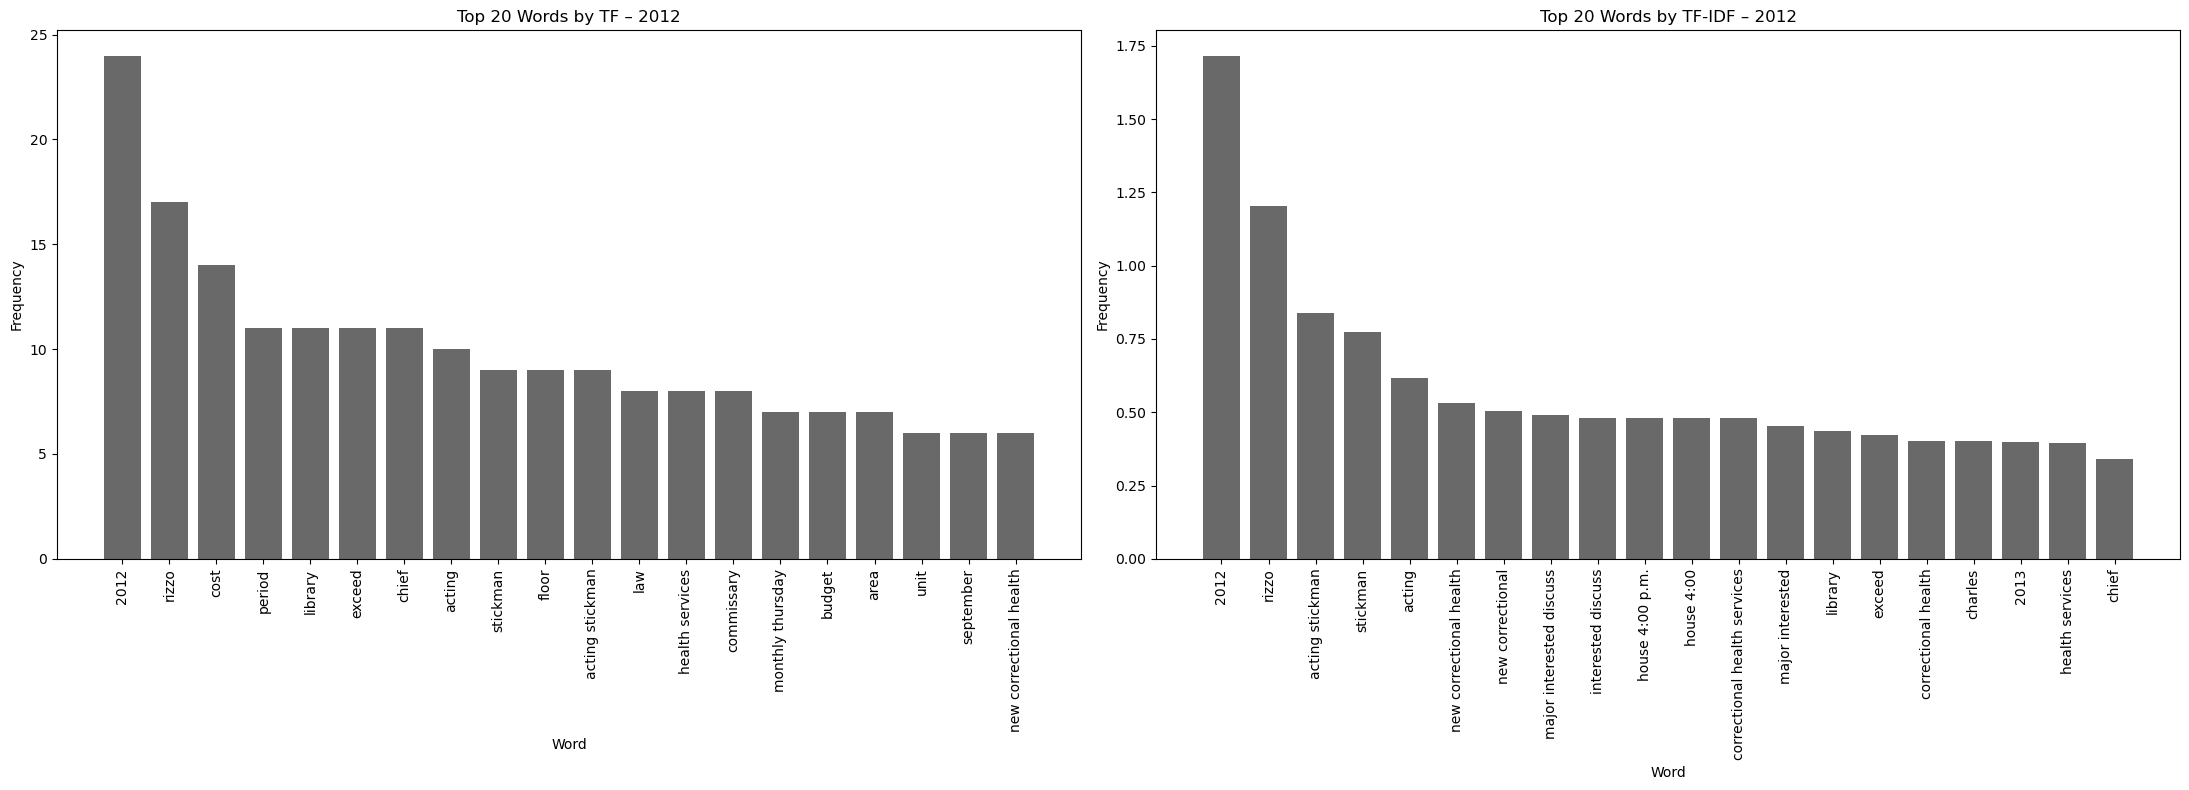

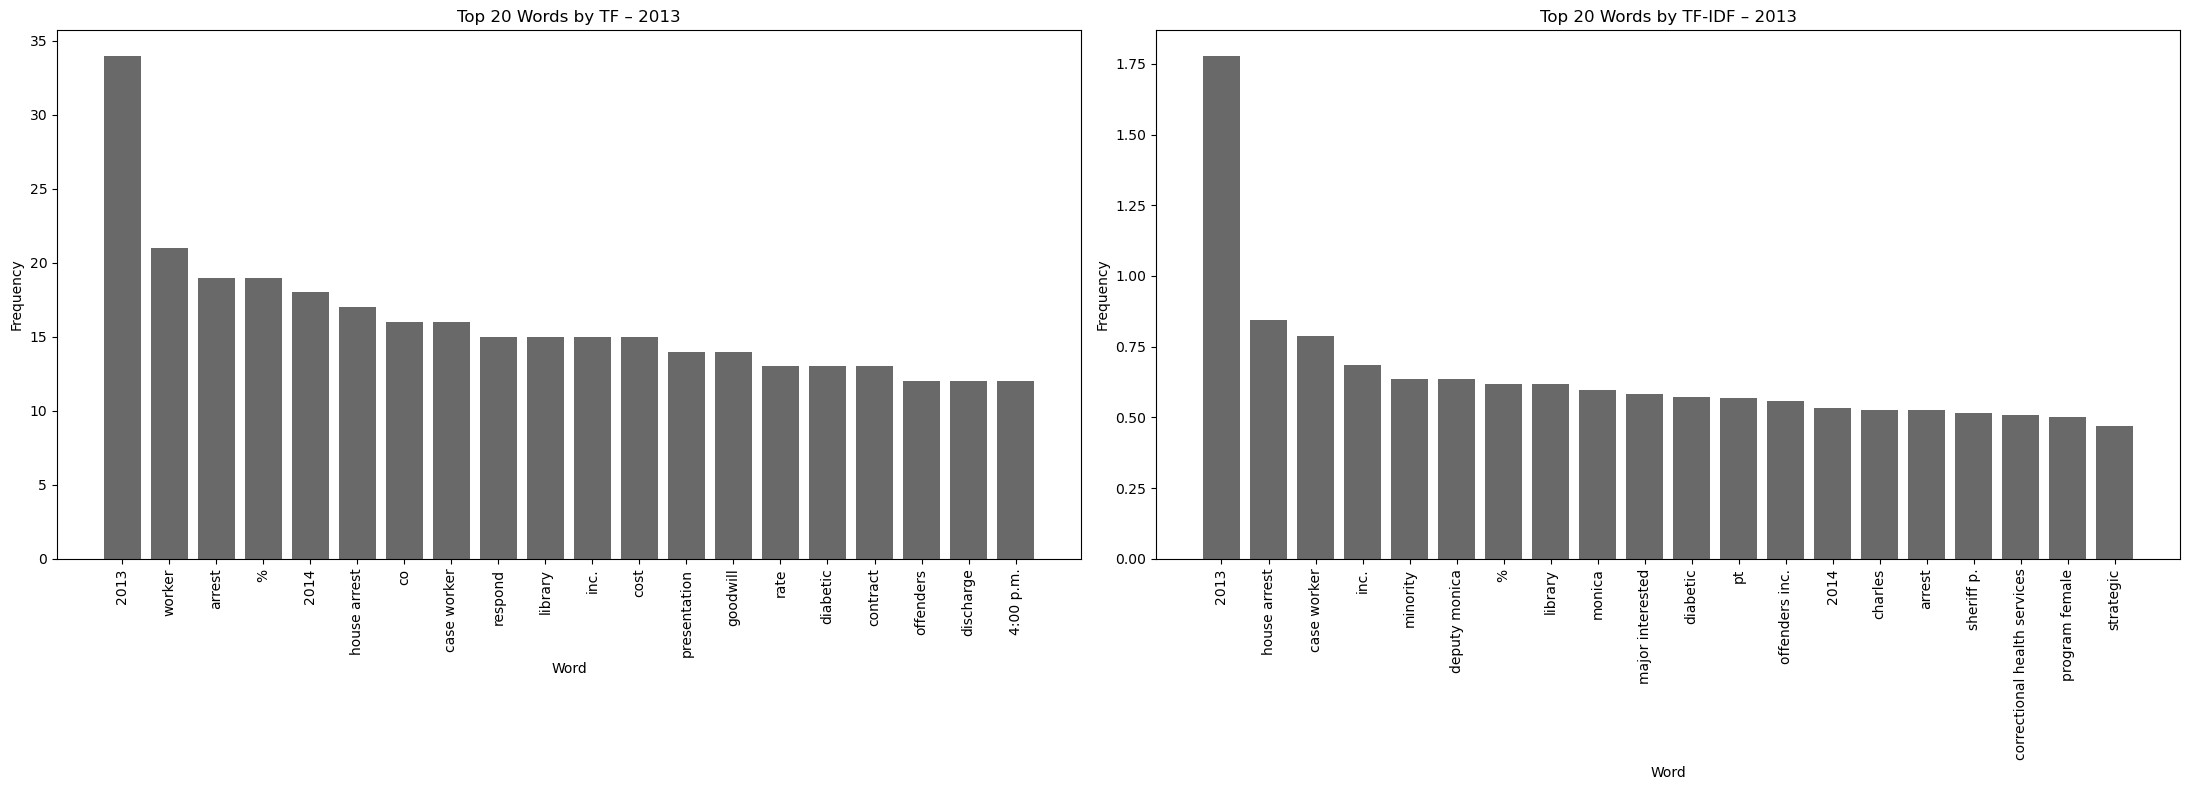

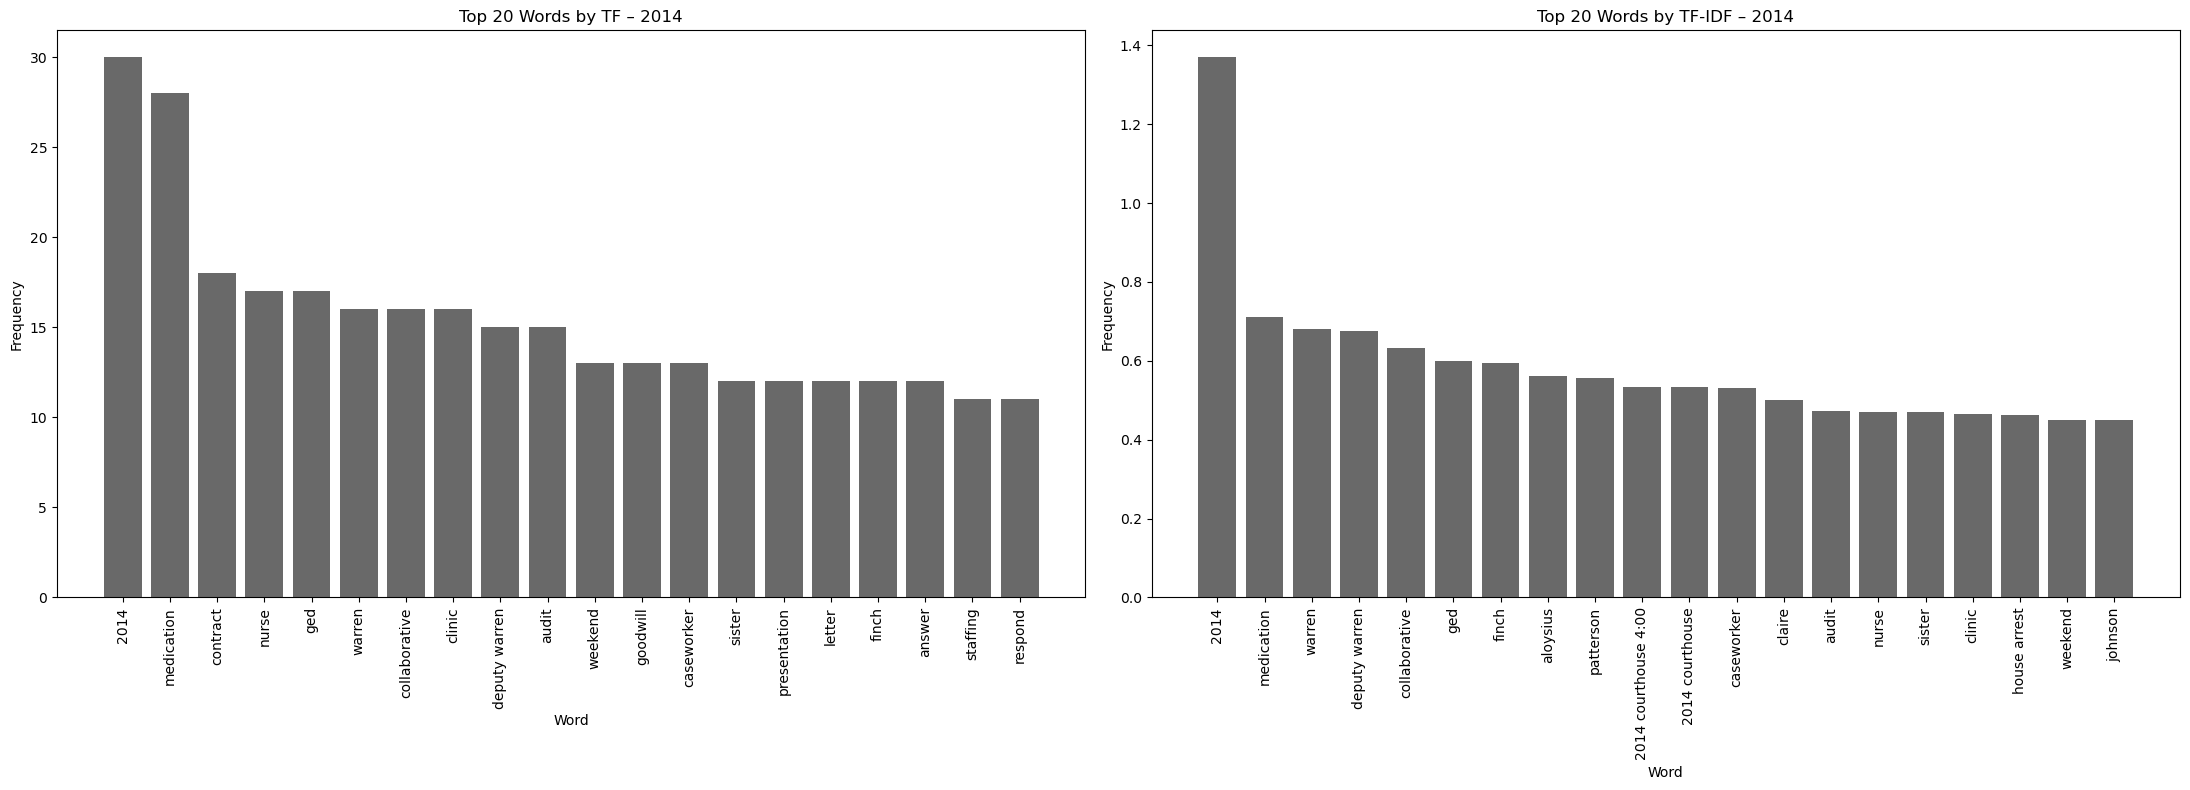

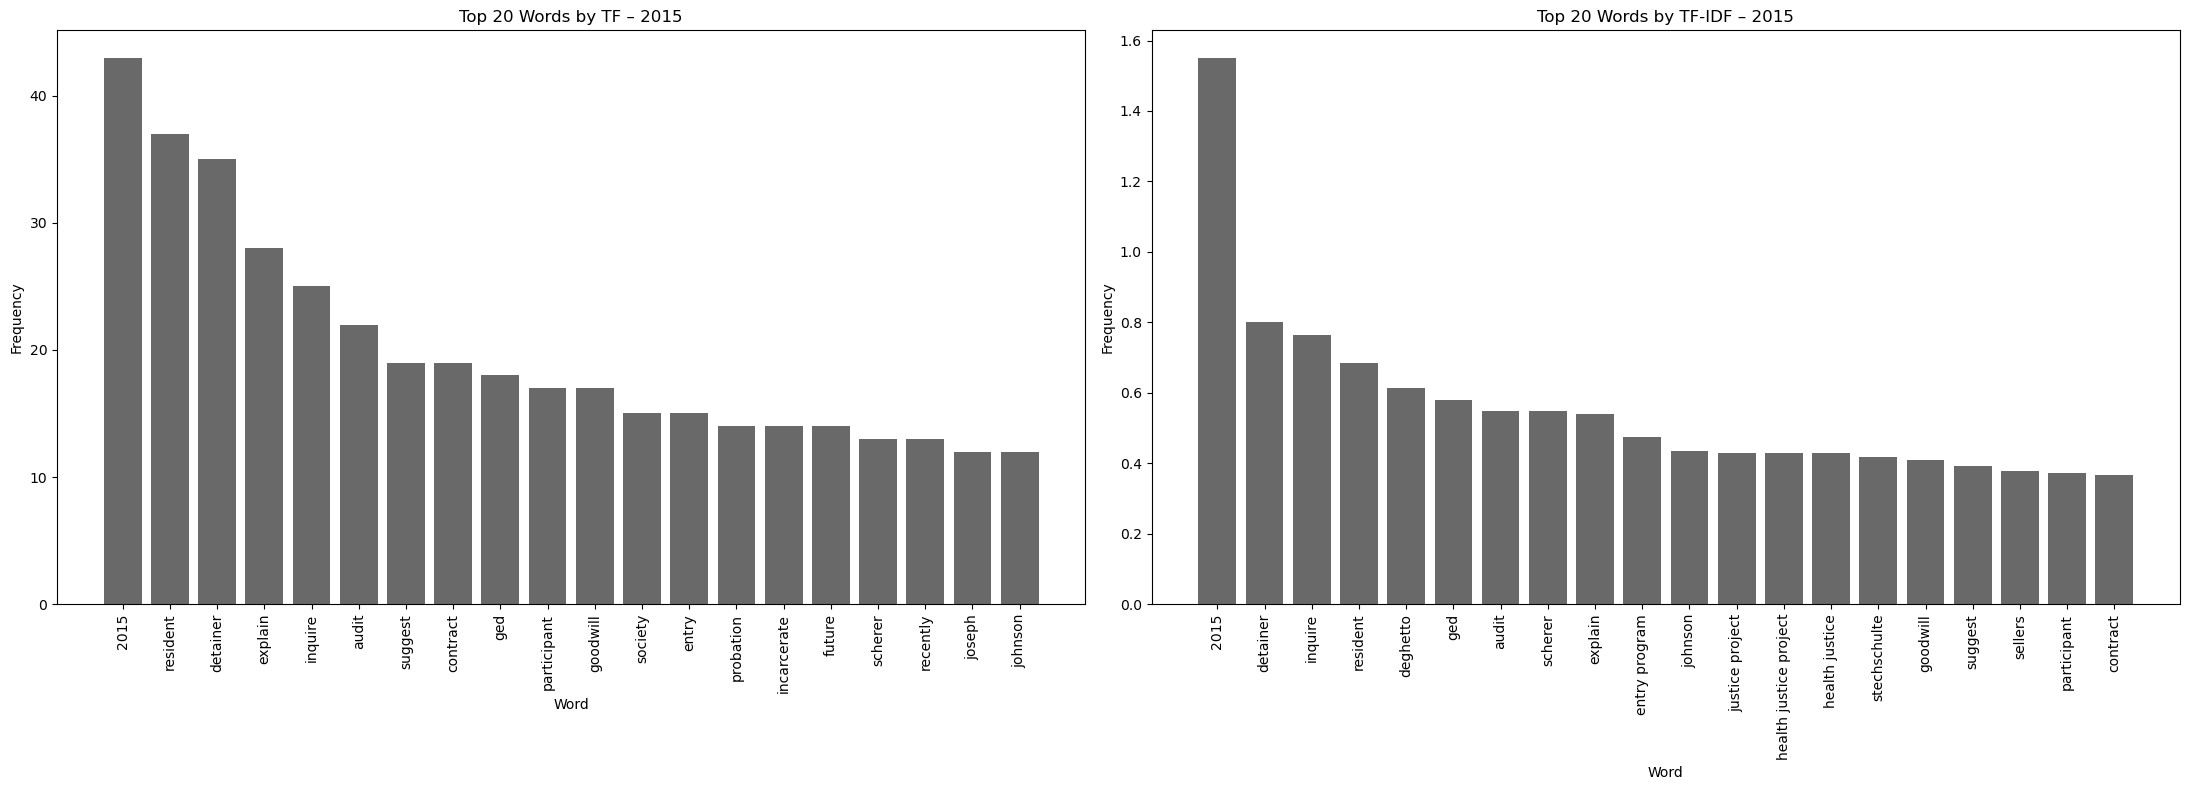

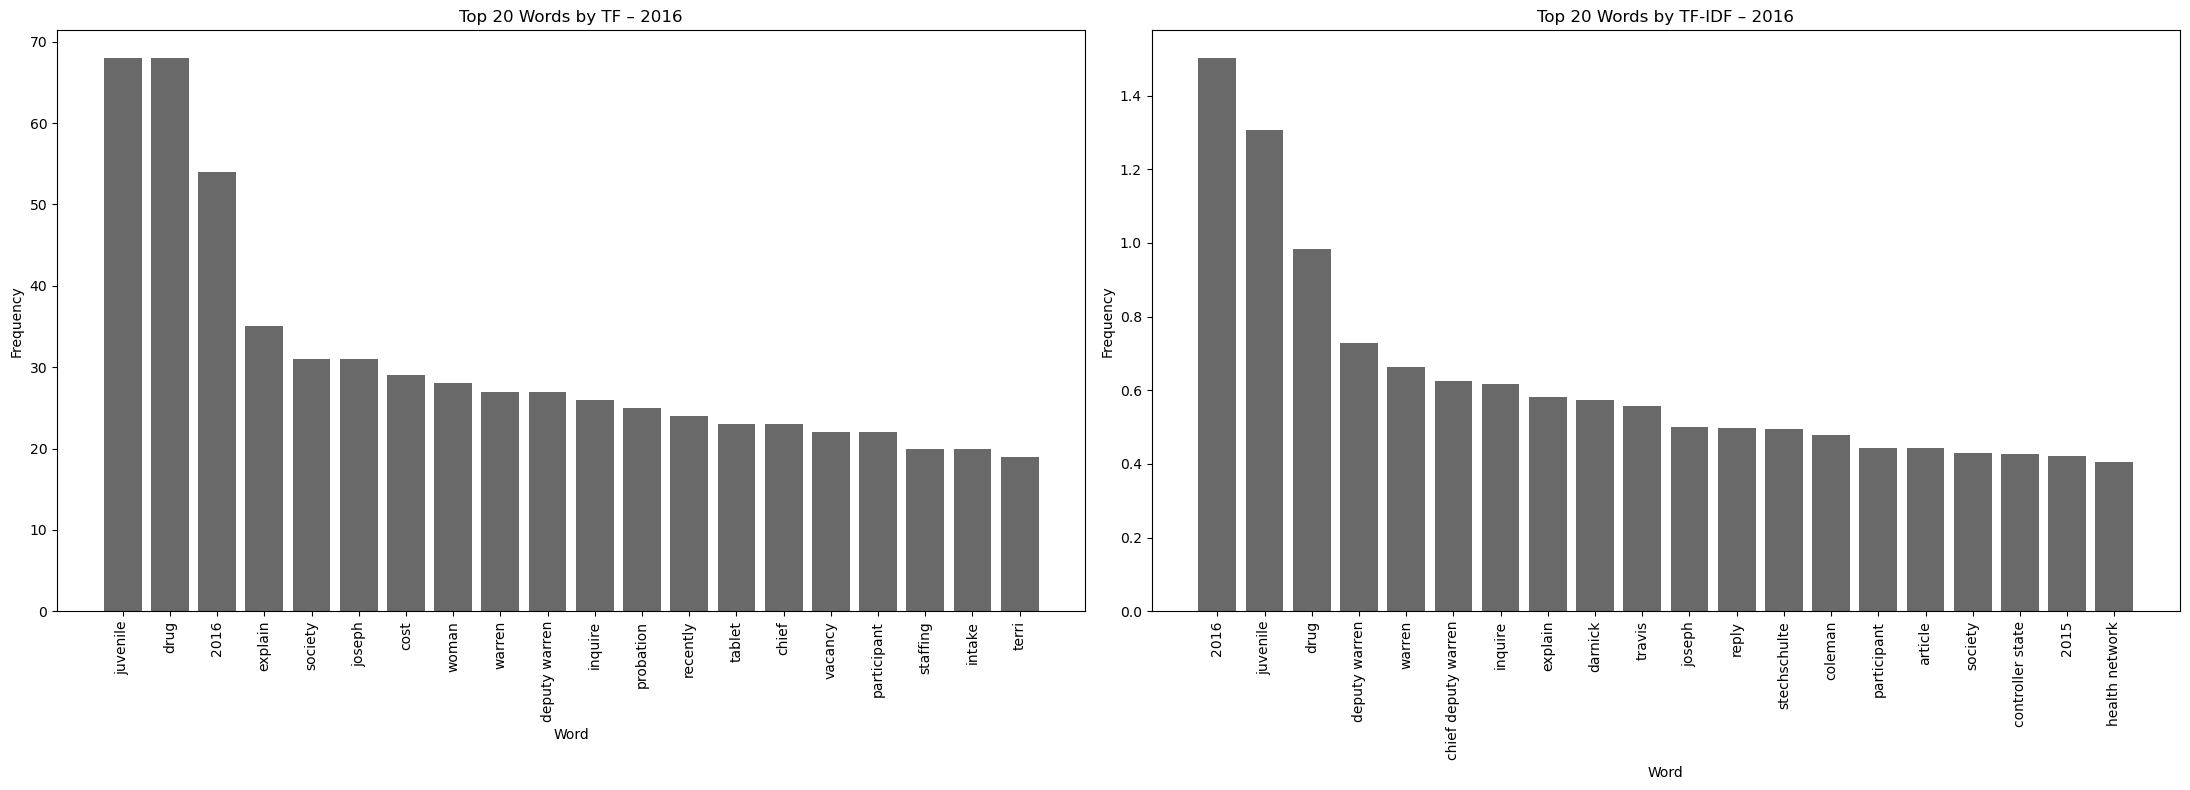

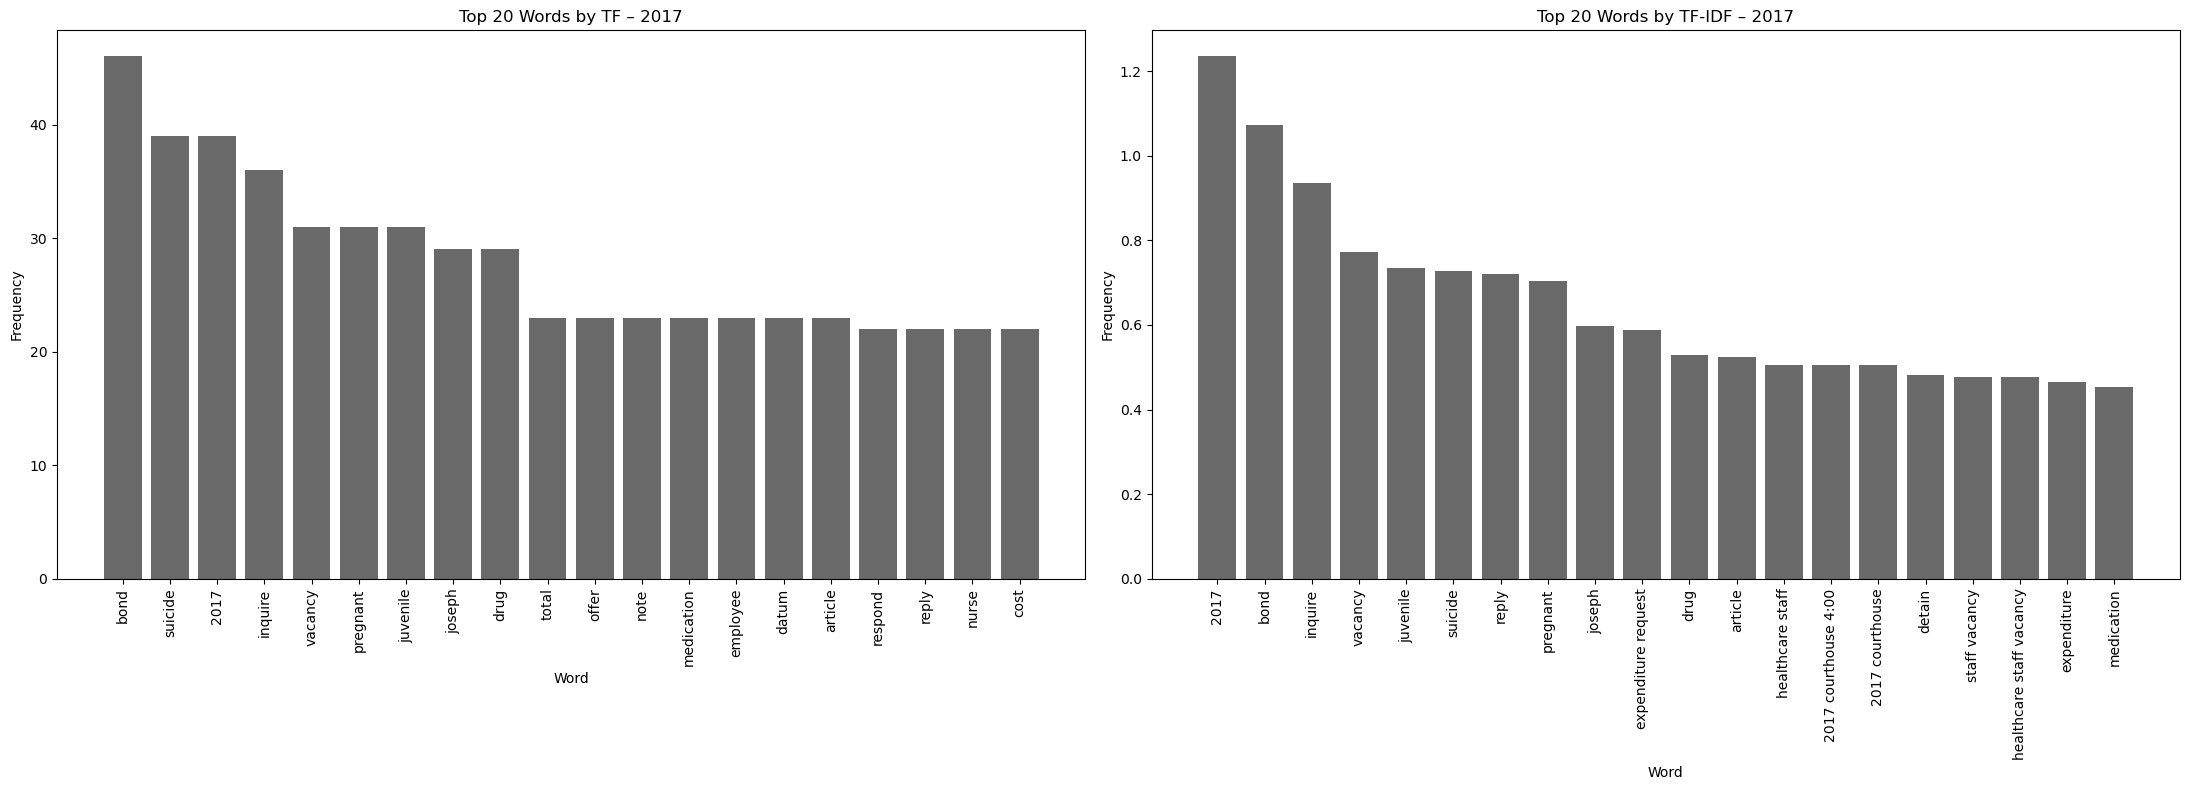

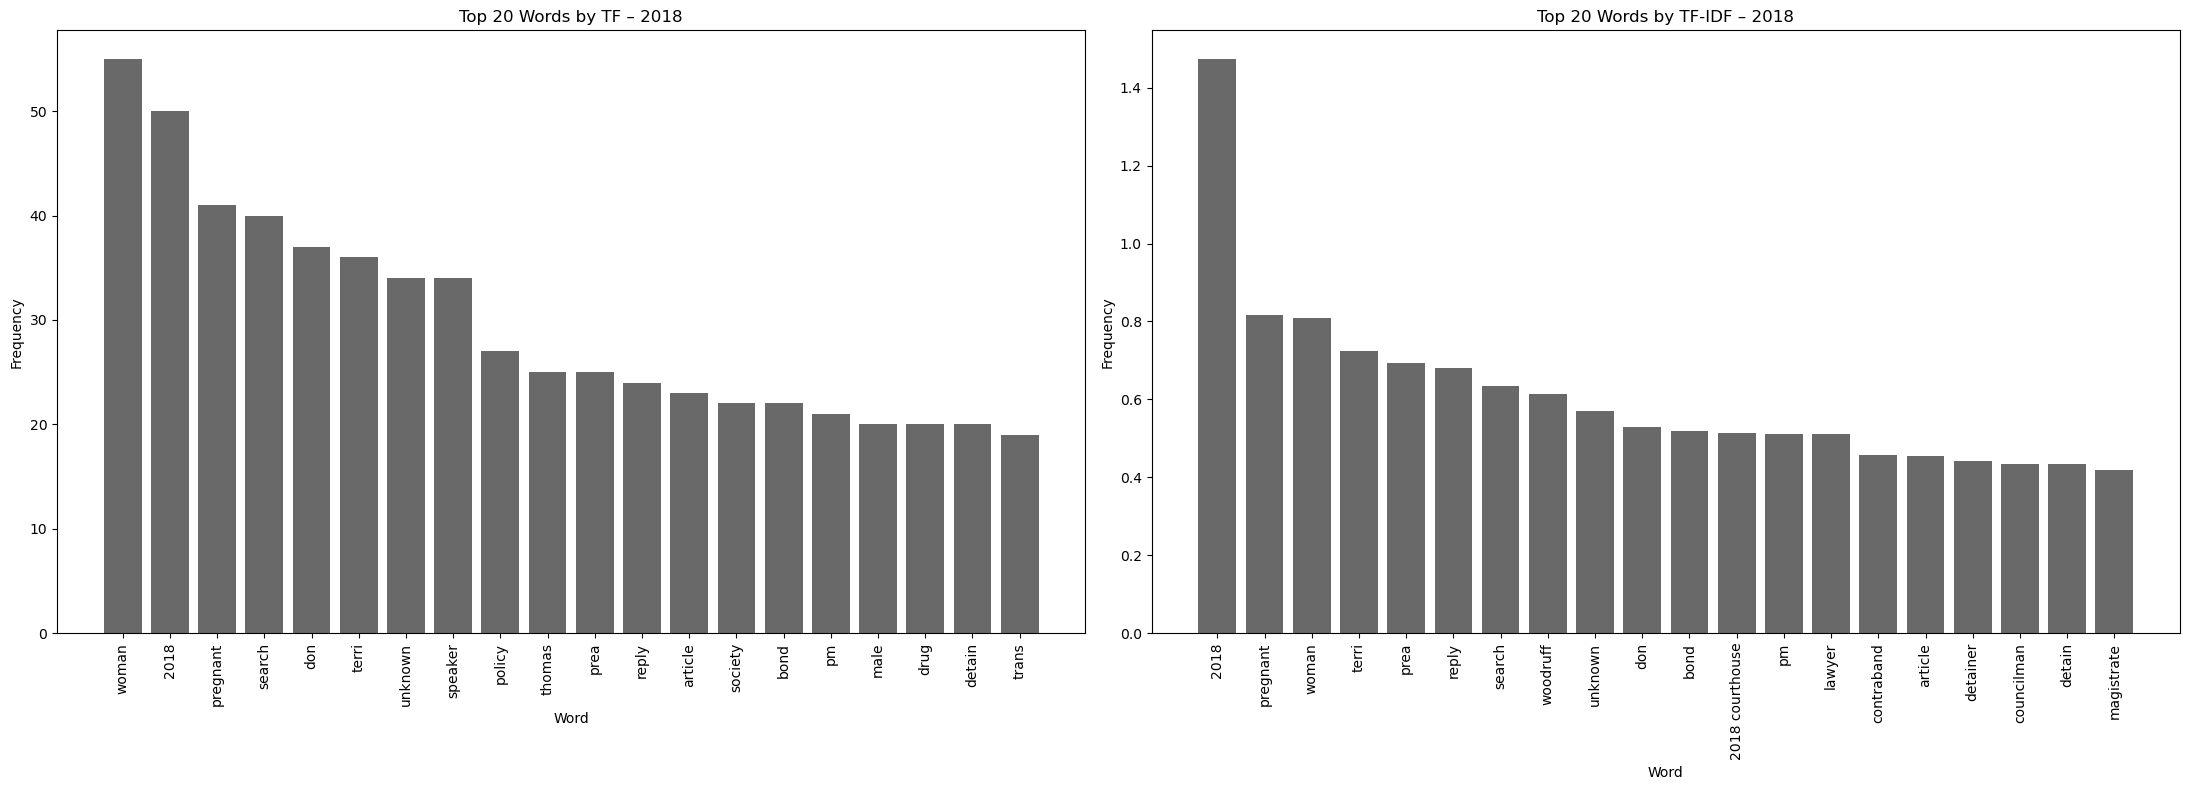

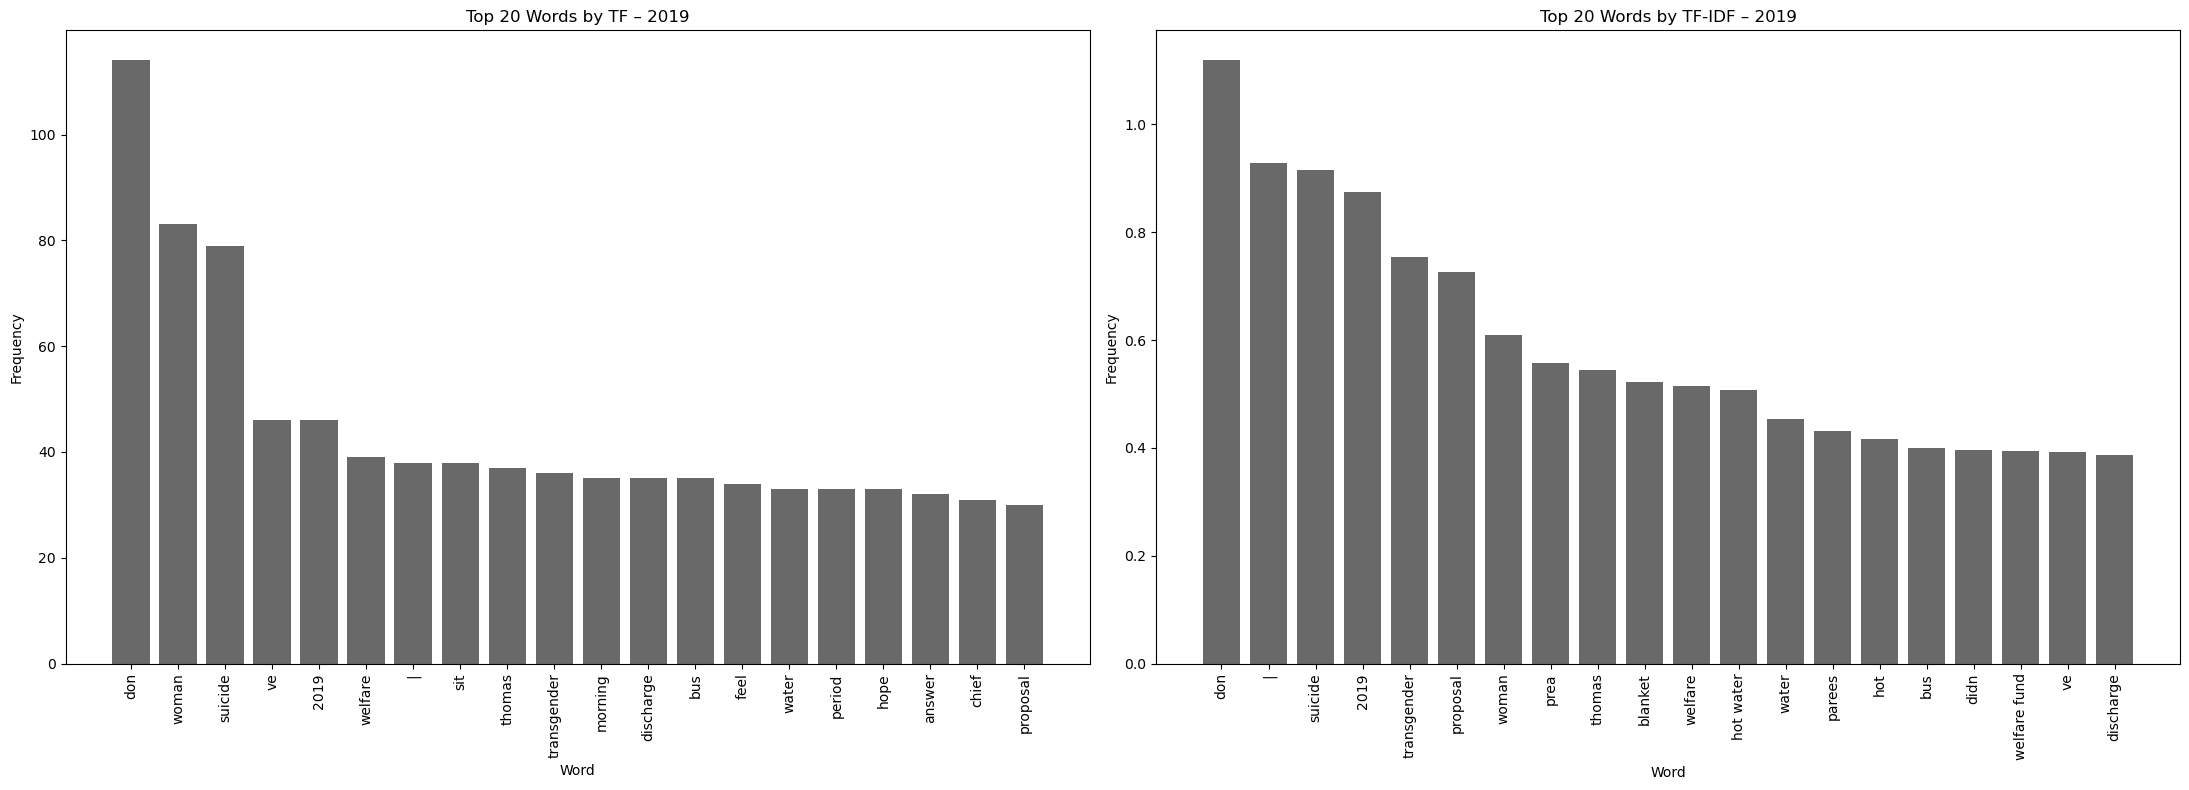

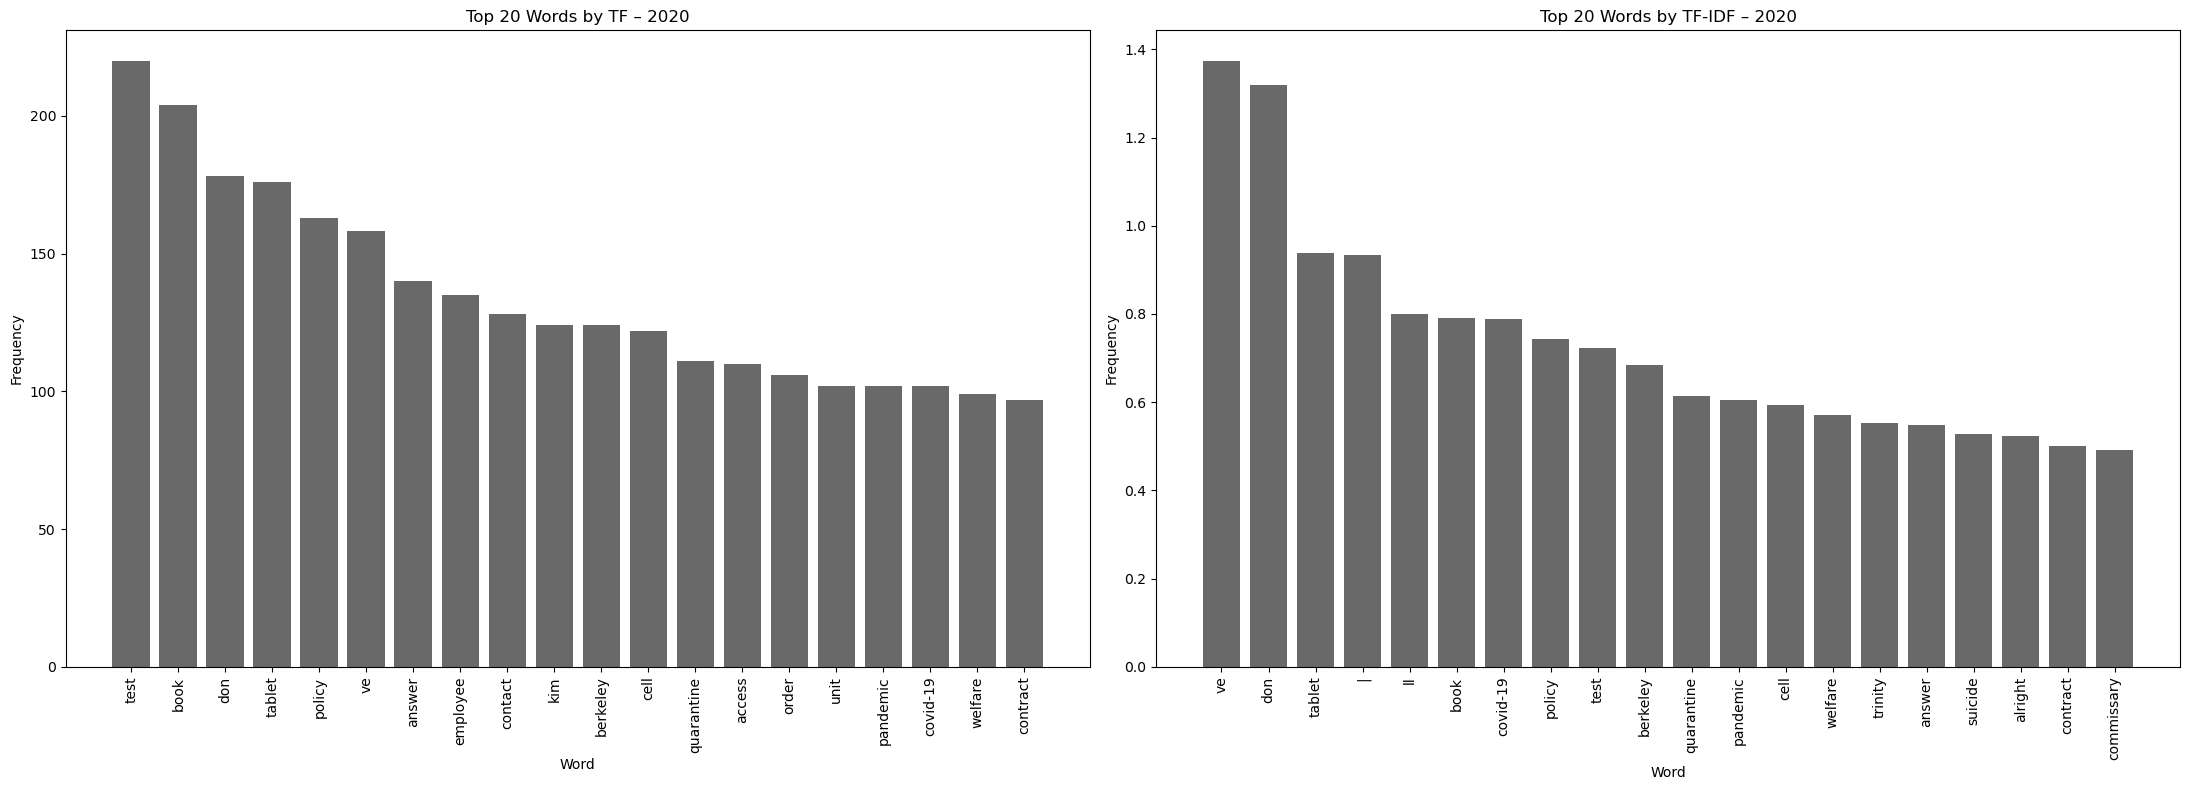

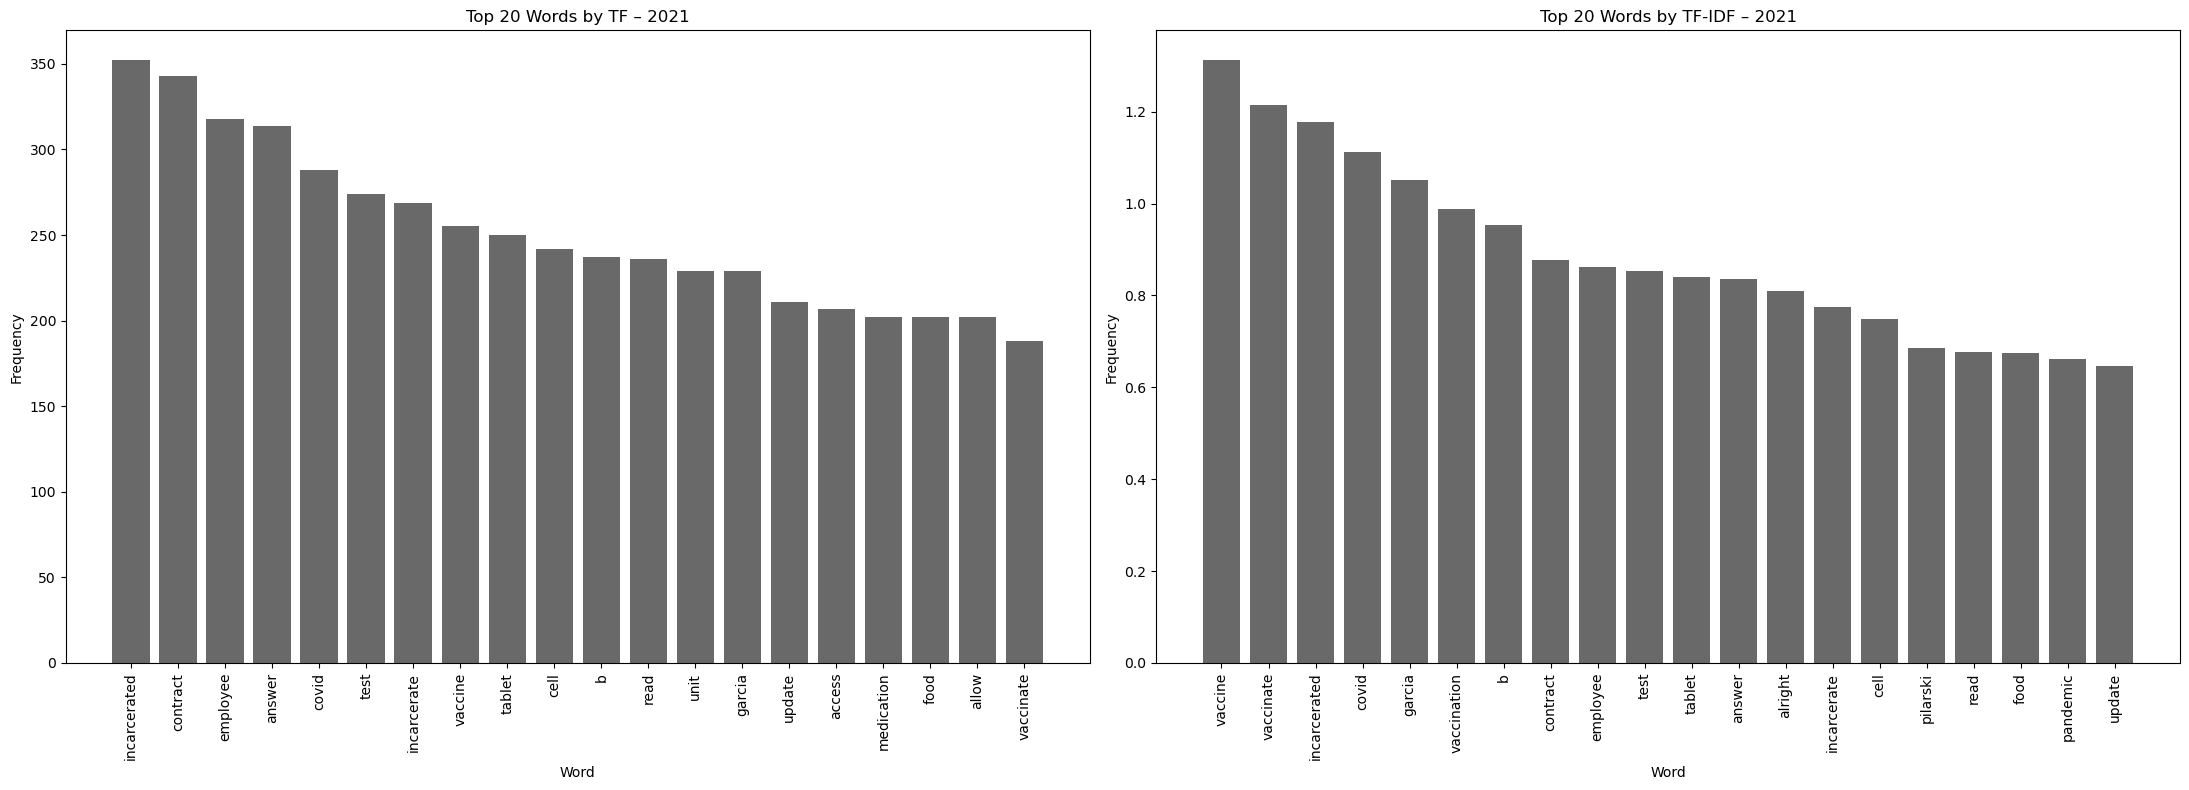

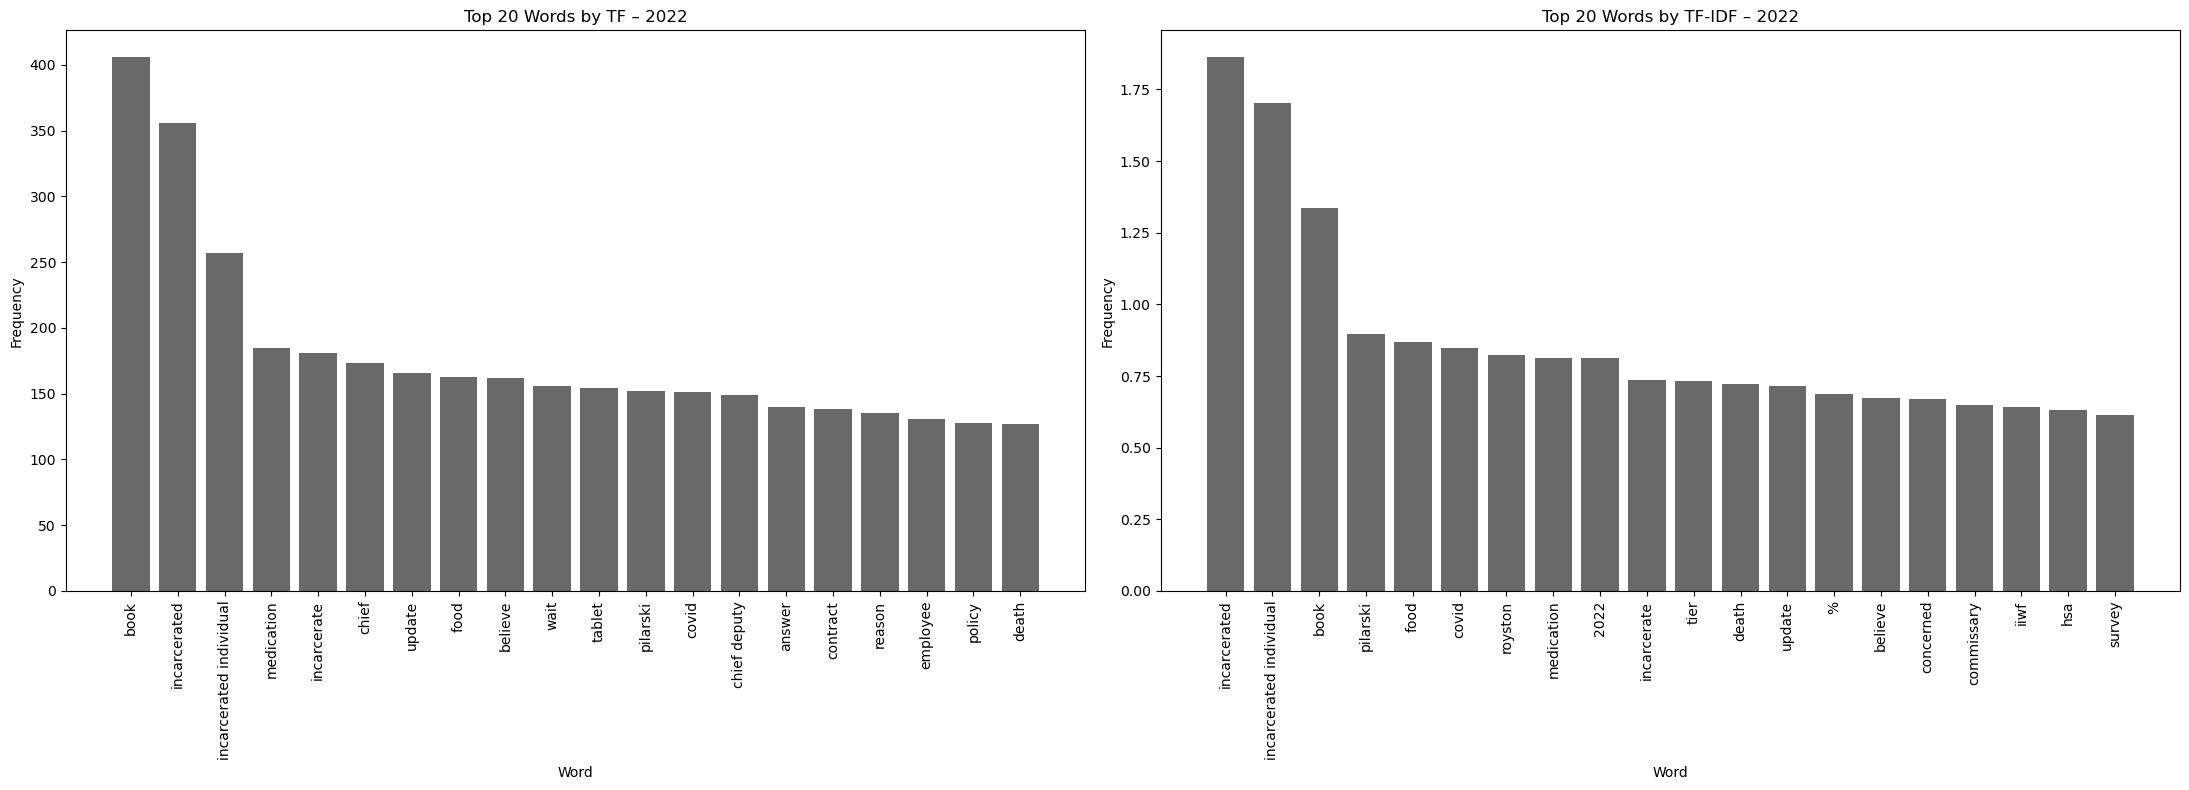

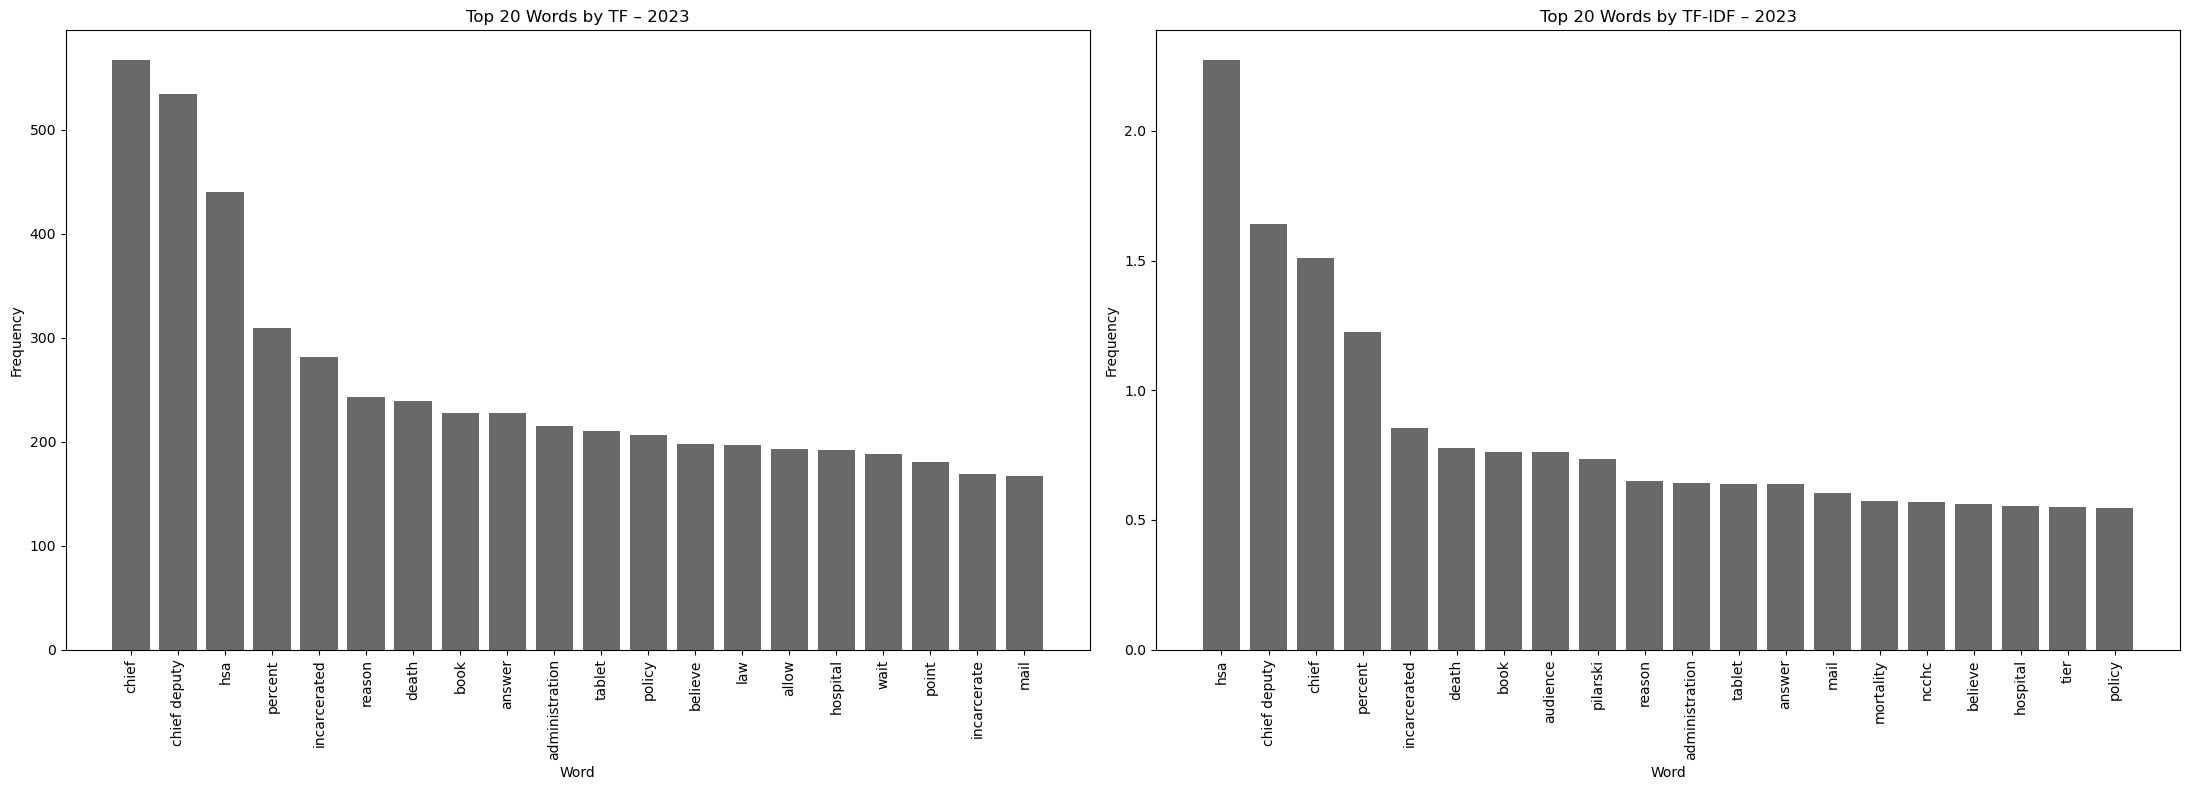

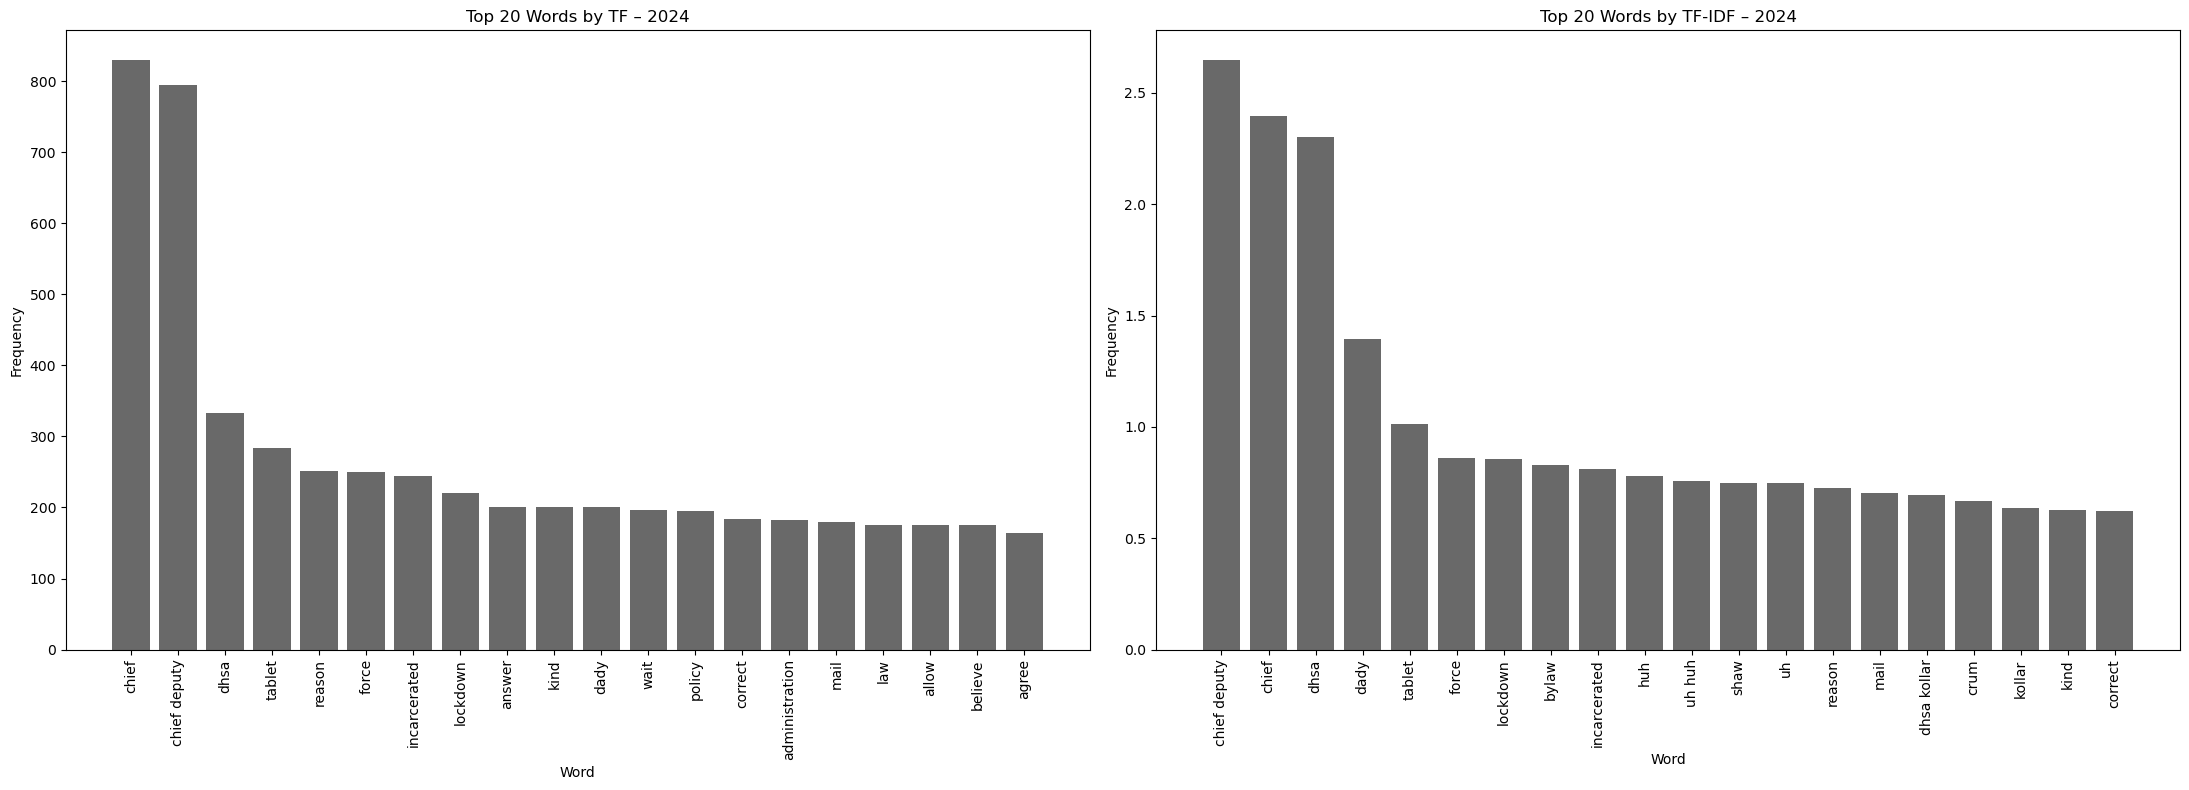

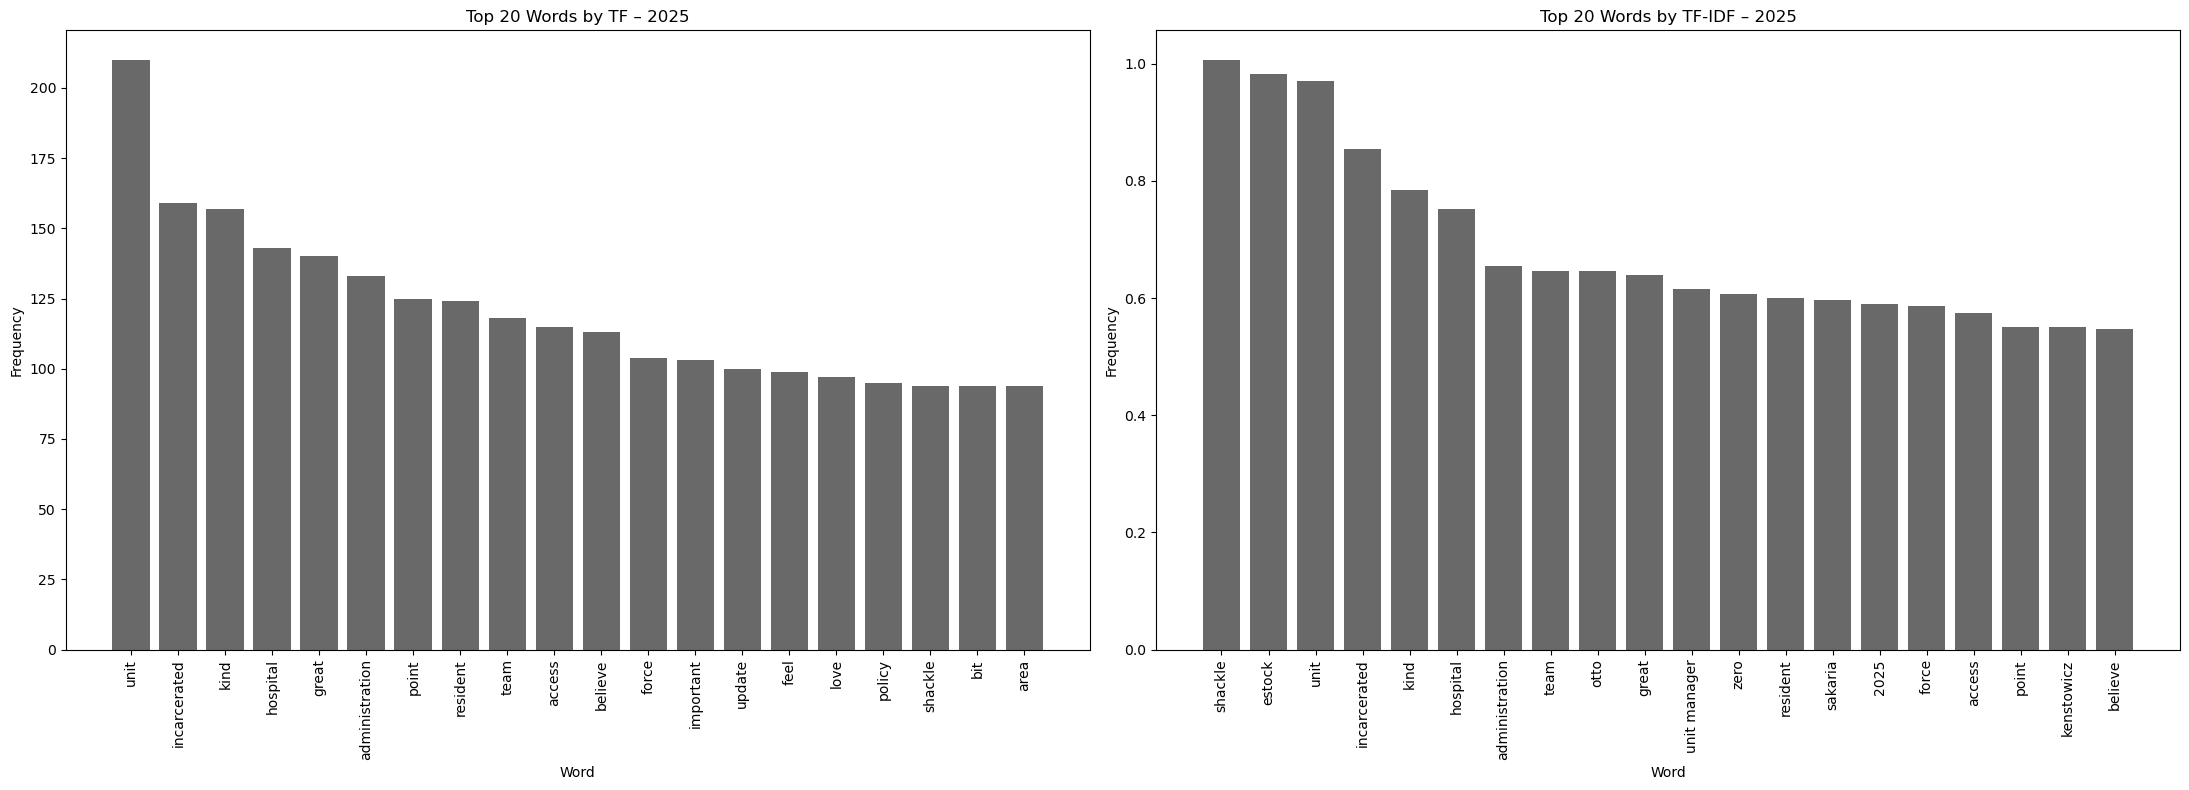

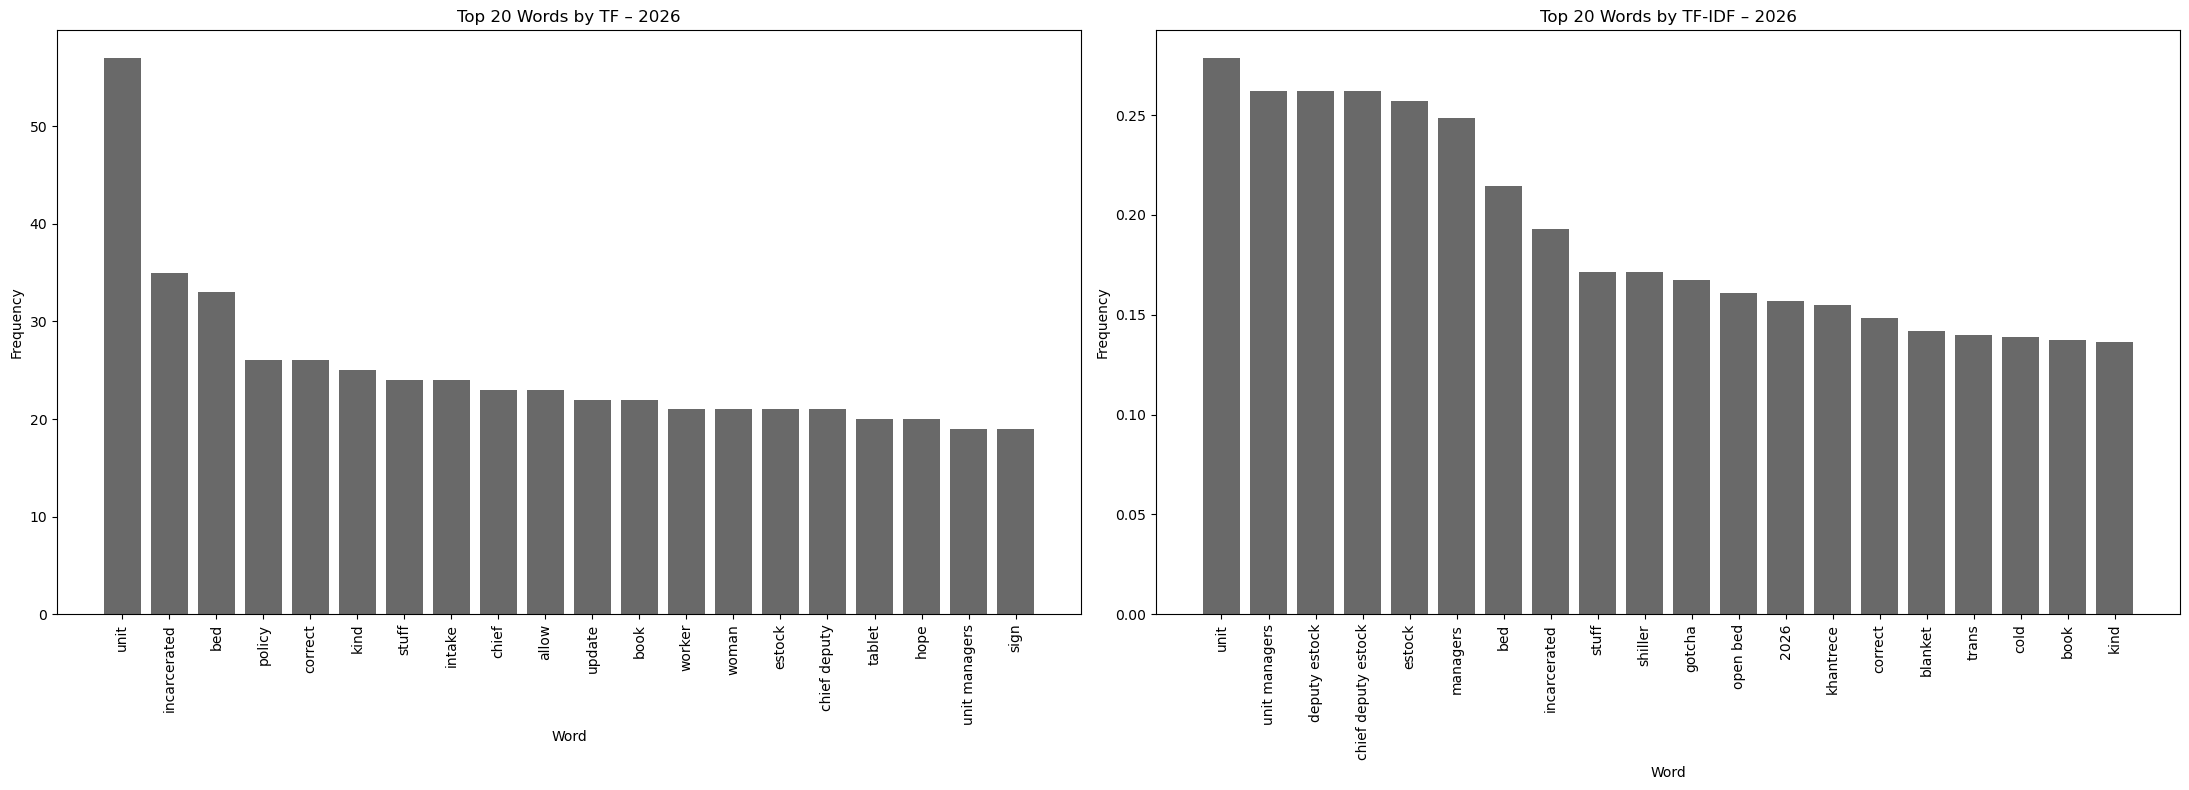

In [120]:
# Looping through each year and making tf and tf-idf plots
unique_years = sorted(df["year"].dropna().unique())

for yr in unique_years:
    year_docs = df.loc[df["year"] == yr, "document"].tolist()
    if not year_docs:
        continue

    tf_year = tf_vectorizer.transform(year_docs)
    tfidf_year = idf_transformer.transform(tf_year)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

    plt.sca(ax1)
    plot_top_words(np.array(tf_year.sum(axis=0)).flatten(), vocab, num_top_words=20)
    ax1.set_title(f"Top 20 Words by TF – {int(yr)}")

    plt.sca(ax2)
    plot_top_words(np.array(tfidf_year.sum(axis=0)).flatten(), vocab, num_top_words=20)
    ax2.set_title(f"Top 20 Words by TF-IDF – {int(yr)}")

    plt.tight_layout()
    plt.show()

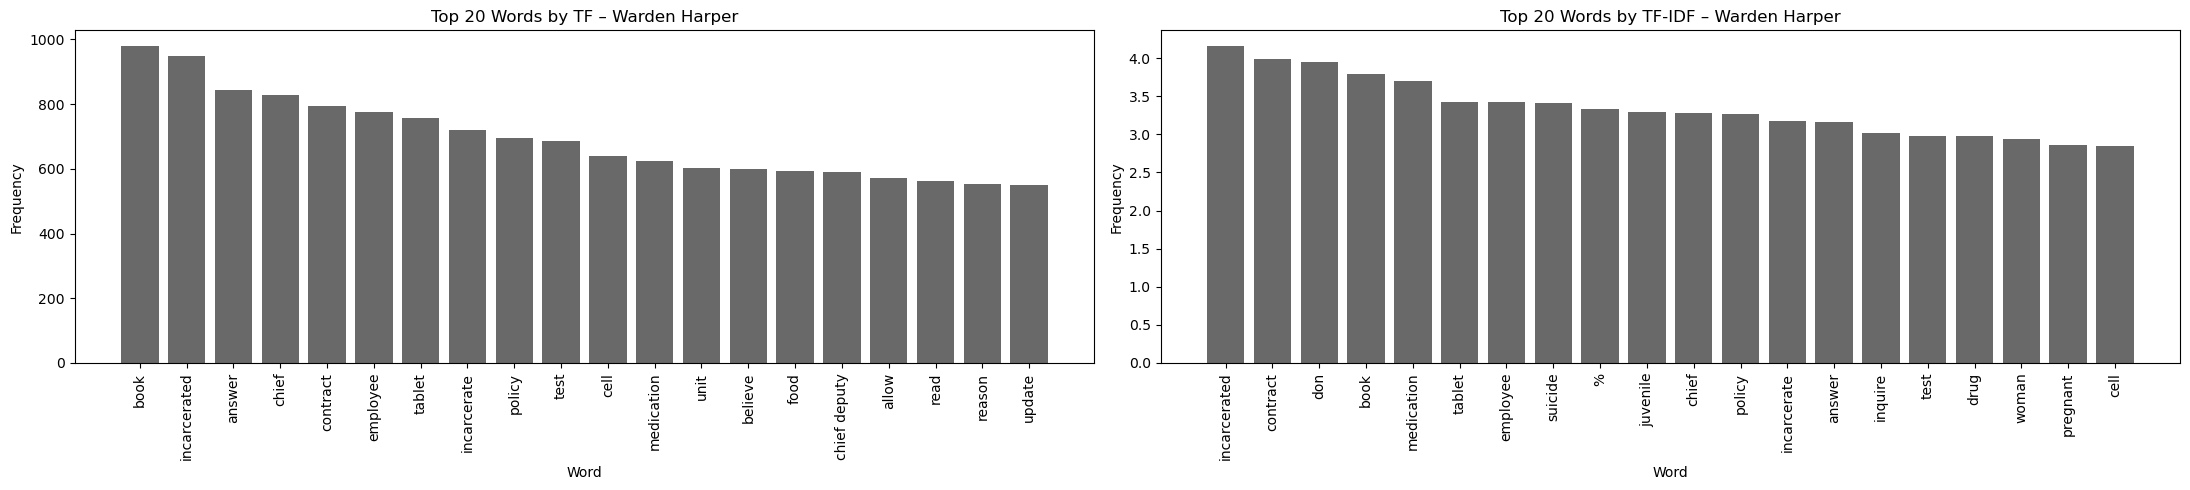

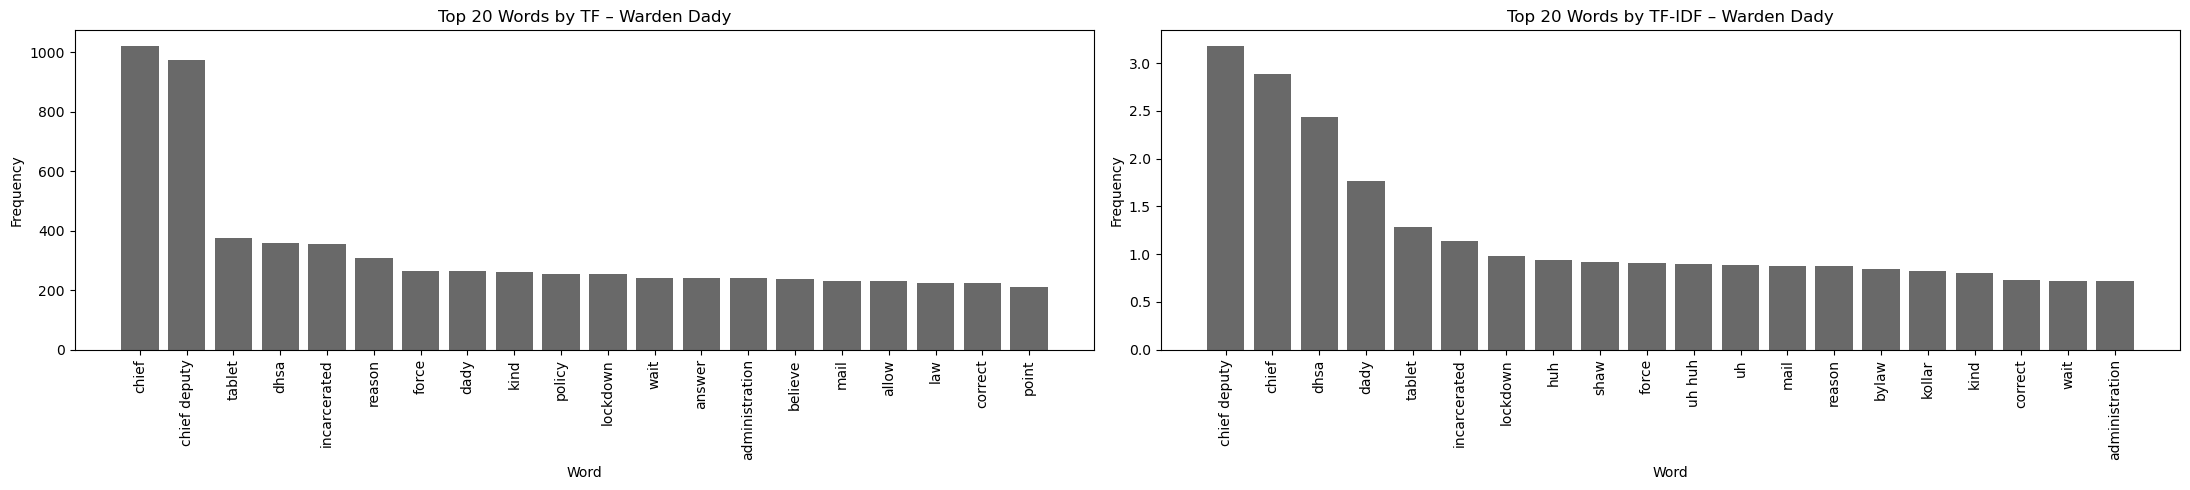

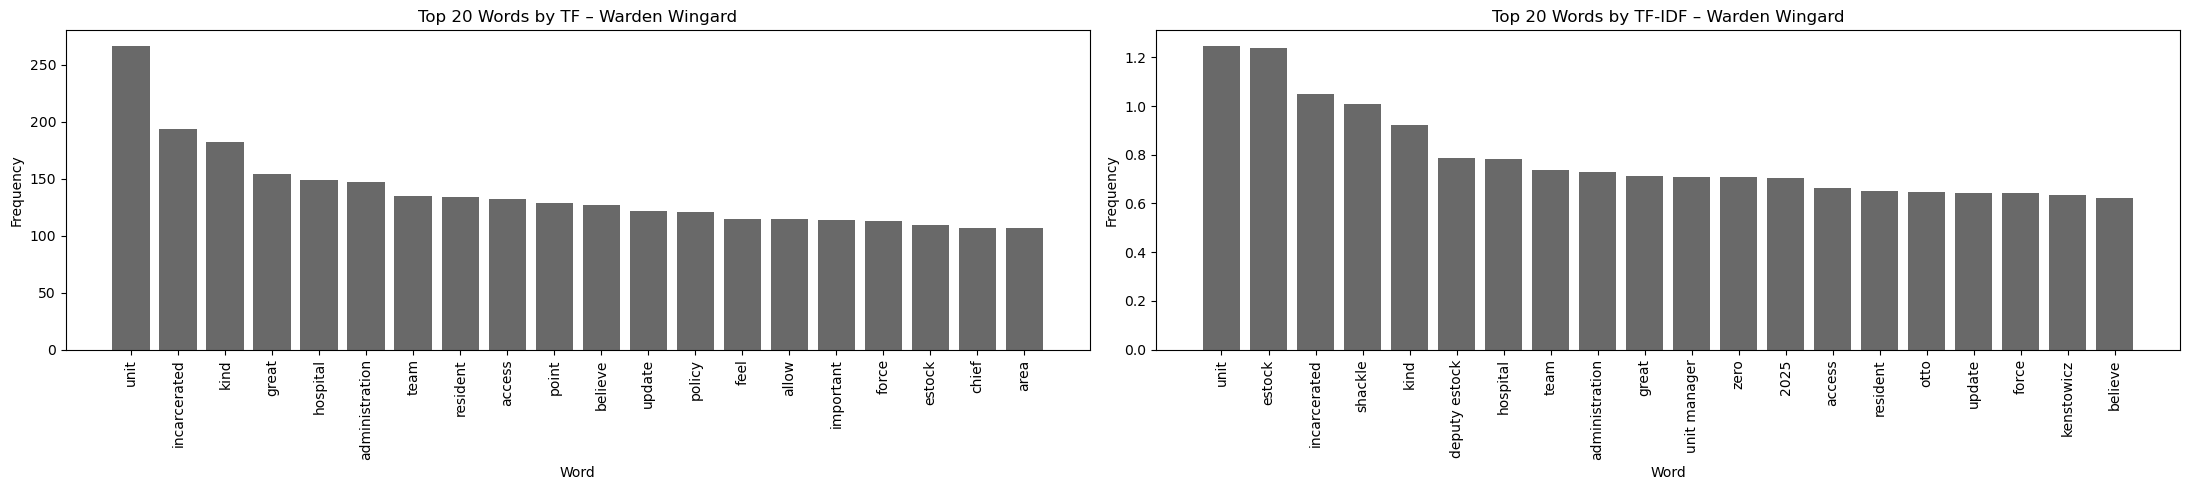

In [121]:
# Looping through each warden period to make tf and tf-idf plots
periods = ["Harper", "Dady", "Wingard"]

for period in periods:
    period_docs = df.loc[df["period"] == period, "document"].tolist()

    tf_period = tf_vectorizer.transform(period_docs)
    tfidf_period = idf_transformer.transform(tf_period)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))

    plt.sca(ax1)
    plot_top_words(np.array(tf_period.sum(axis=0)).flatten(), vocab, num_top_words=20)
    ax1.set_title(f"Top 20 Words by TF – Warden {period}")

    plt.sca(ax2)
    plot_top_words(np.array(tfidf_period.sum(axis=0)).flatten(), vocab, num_top_words=20)
    ax2.set_title(f"Top 20 Words by TF-IDF – Warden {period}")

    plt.tight_layout()
    plt.show()

### Looking at n-gram frequency over time

In [122]:
# Printing vocab list to find n-grams to track
print(list(vocab))
print('\n')

['%', '% %', '% employee', '% population', '% positive', '% receive', '% staff', '&', '& noble', '*', '+', '-19', '-assiste', '-assiste treatment', '-base', '-based', '-day', '-day lockdown', '-ended', '-in', '-line', '-line staff', '-making', '-on', '-ordere', '-out', '-relate', '-searche', '-searched', '-term', '-term solitary', '-term solitary confinement', '-to', '-up', '-up question', '-wide', '-wide lockdown', '-year', '.com', '/client', '1,000', '1,500', '1,800', '1,859', '10,000', '100,000', '100.00 =', '100.00 = total', '10:00', '10:30', '10th', '11:00', '11th', '12:00', '12th', '13th', '13th amendment', '14th', '15th', '16th', '17th', '18th', '19th', '1:00', '1a', '1b', '1st', '2,000', '2,075', '2,500', '2.5', '20,000', '20,000 book', '2000', '2009', '2012', '2013', '2014', '2014 courthouse', '2014 courthouse 4:00', '2015', '2016', '2017', '2017 courthouse', '2017 courthouse 4:00', '2018', '2018 2019', '2018 courthouse', '2018 courthouse 4:00', '2019', '2020', '2021', '2021 c

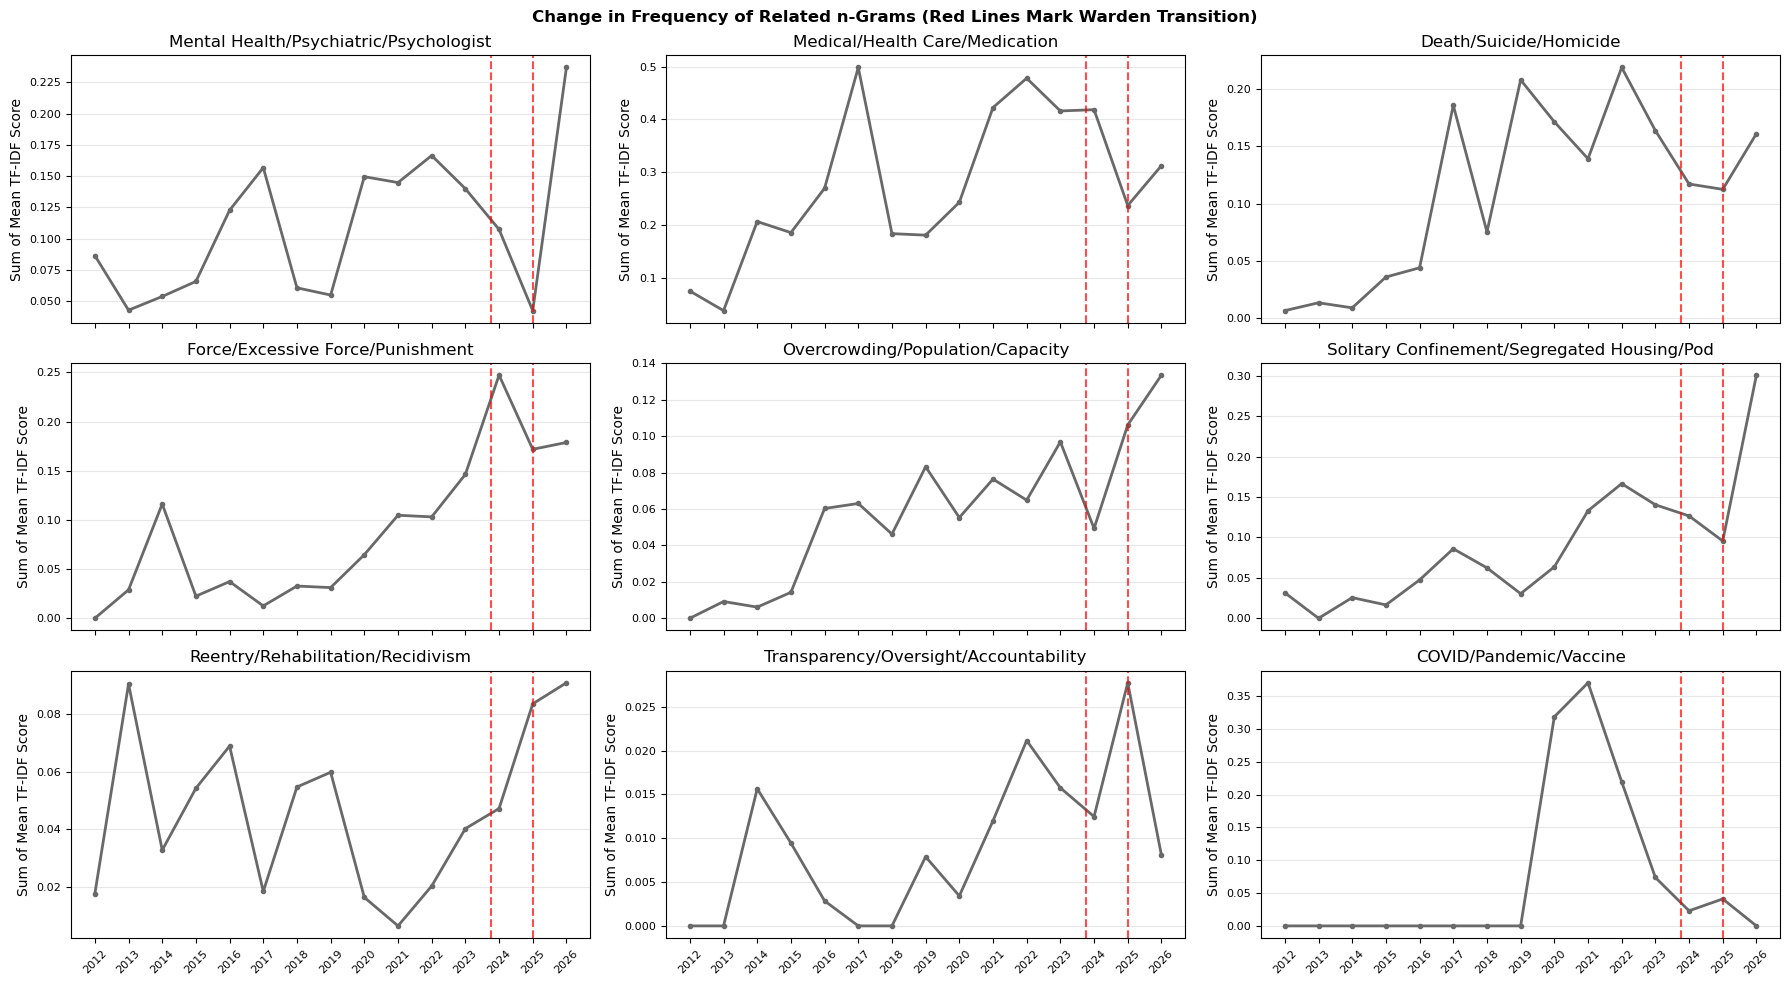

In [123]:
# Defining related n-grams
related_ngrams = {
    'Mental Health/Psychiatric/Psychologist': ['mental health', 'psychiatric', 'psychologist'],
    'Medical/Health Care/Medication': ['medical', 'healthcare', 'health care', 'medication'],
    'Death/Suicide/Homicide': ['death', 'suicide', 'homicide'],
    'Force/Excessive Force/Punishment': ['force','excessive force', 'punishment'],
    'Overcrowding/Population/Capacity': ['overcrowding', 'population', 'capacity'],
    'Solitary Confinement/Segregated Housing/Pod': ['solitary confinement', 'segregated housing', 'pod', 'pods'],
    'Reentry/Rehabilitation/Recidivism': ['reentry', 're-entry', 'rehabilitation', 'recidivism'],
    'Transparency/Oversight/Accountability': ['transparency','oversight','accountability'],
    'COVID/Pandemic/Vaccine': ['covid', 'pandemic', 'quarantine'],
}

# Returns indices of vocab terms that match any ngram for a given topic
def get_ngram_indices(group_ngrams, vocab):
    indices = []
    for i, v in enumerate(vocab):
        for kw in group_ngrams:
            if kw in v:
                indices.append(i)
    return indices

# Map each ngram to its matching vocab indices
ngram_indices = {}
for ngram, keywords in related_ngrams.items():
    idx = get_ngram_indices(keywords, vocab)
    ngram_indices[ngram] = idx

# Compute mean TF-IDF per ngram group per year
ngram_trends = pd.DataFrame(index=sorted(unique_years), columns=related_ngrams.keys(), dtype=float)

for yr in unique_years:
    year_docs = df.loc[df["year"] == yr, "document"].tolist()
    tf_yr = tf_vectorizer.transform(year_docs)
    tfidf_yr = idf_transformer.transform(tf_yr)
    mean_tfidf = np.array(tfidf_yr.mean(axis=0)).flatten()

    for ngrams, idx in ngram_indices.items():
        if idx:
            ngram_trends.loc[yr, ngrams] = mean_tfidf[idx].sum()
        else:
            ngram_trends.loc[yr, ngrams] = 0.0

# Plotting results and defining warden tenure
fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for i, group in enumerate(ngram_trends.columns):
    ax = axes[i]
    vals = ngram_trends[group]
    ax.plot(vals.index, vals, marker='o', markersize=3, linewidth=2, color='dimgrey')
    ax.set_title(group)
    ax.set_xticks(ngram_trends.index)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel('Sum of Mean TF-IDF Score')

    ax.axvline(x=2023.75, color='red', linestyle='--', alpha=0.7)
    ax.axvline(x=2025, color='red', linestyle='--', alpha=0.7)


fig.suptitle('Change in Frequency of Related n-Grams (Red Lines Mark Warden Transition)', fontweight='bold')

plt.tight_layout()
plt.show()